# EnergyScope Results Analysis - Norte Amazonica

**EnergyScope MultiCell** optimisation of the *Norte Amazonica* region (Bolivia), represented by **5 clustered cells** (C1-C5) that preserve differences in grid connectivity, population density and existing infrastructure.

**Research question**: *how should this isolated region plan its energy transition under different demand and transition scenarios?*

This notebook analyses **one scenario** in detail (`SCENARIO`, defined below), then compares in section 10 **universal sufficiency** (reference) against **current system**, **supply transition** (centralised grid reinforcement) and **universal access** (decentralised access via home systems + grid extension), and produces in section 11 six publication-ready figures for thesis chapter 5.

## Plan
1. Executive summary - corrected indicators
2. **End-use demand** - what drives the system
3. **Autonomy & imports** - external dependence by region
4. Carbon footprint (GWP) + intensity
5. Storage
6. Curtailment & flexibility
7. Inter-regional exchanges
8. Hourly profiles - electric dispatch vs demand
9. Synthesis
10. **Scenario comparison** - universal sufficiency vs current system vs supply transition vs universal access
11. **Chapter 5 figures** - supply mix, costs, hot water, access comparison, off-grid match, cost waterfall, scenario comparison, cost-emissions trade-off, hot-water sensitivity

---
**Units**: costs in M€/year . energy in GWh/year . capacity in GW . GWP in kt CO2-eq/year


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

In [80]:
# ============================================================================
#  CONFIGURATION  -  change SCENARIO to analyse / compare another run
# ============================================================================
ROOT = Path('case_studies/C1_C2_C3_C4_C5')
DATA = Path('Data/2025')     # inputs are now split per demand scenario: sufficiency/ and reality/

# -- Main scenario, analysed in detail in sections 1-11 ----------------------
SCENARIO = 'norte_amazonia_sufficiency_2025'
DATA_DIR = DATA / 'sufficiency'          # input folder matching SCENARIO

BASE   = ROOT / SCENARIO / 'outputs'
REG    = BASE / 'regional_results'
HOURLY = BASE / 'hourly_results'

# -- Comparison set, section 12 ---------------------------------------------
SCEN_REF = 'Universal sufficiency'    # reference against which deltas are computed
COMPARE = {
    'Universal sufficiency': 'norte_amazonia_sufficiency_2025',
    'Current system':        'norte_amazonia_reality_2025',
    'Supply transition':     'norte_amazonia_reality_2025_phase2',
    'Universal access':      'norte_amazonia_reality_access_2025',
    'Access transition':     'norte_amazonia_access_transition_2025',
}
# Scenarios that connect every dispersed household to the grid, hence carry the
# BC grid-extension CAPEX (see section 12.4): Universal sufficiency (full
# regional redesign), Universal access and Access transition (dedicated home
# systems, same spatial classification as Universal access). Supply
# transition only reinforces the existing centralised grid - it creates no new
# connections, same as Current system -> 0 for both.
GRID_EXT_SCEN = {'Universal sufficiency', 'Universal access', 'Access transition'}
SCEN_COLORS = {'Universal sufficiency': '#E4848F', 'Current system': '#8FC7A8',
               'Supply transition': '#5A9AE3', 'Universal access': '#D9A441',
               'Access transition': '#8B6DAE'}

REGIONS = ['C1', 'C2', 'C3', 'C4', 'C5']
# Human-readable labels (fill in with the actual cluster geography)
REGION_LABELS = {r: r for r in REGIONS}

EPS = 1e-6   # seuil "non nul"

# -- Storage technologies (to exclude from production mixes) -----------------
STORAGE_TECHS = {'BATT_LI', 'BATT_HS', 'CAES', 'PHS', 'DAM_STORAGE', 'TS_DEC_HP_ELEC',
                 'TS_HIGH_TEMP', 'GAS_STORAGE', 'H2_STORAGE', 'DIESEL_STORAGE',
                 'LPG_STORAGE', 'GASOLINE_STORAGE', 'JET_FUEL_STORAGE', 'LNG_STORAGE',
                 'AMMONIA_STORAGE', 'METHANOL_STORAGE', 'CO2_STORAGE'}

# -- Renewable / fossil / import classification for the electricity vector ----
RENEW_ELEC  = {'PV_UTILITY', 'PV_ROOFTOP', 'PV_HS', 'WIND_ONSHORE', 'WIND_OFFSHORE',
               'HYDRO_DAM', 'HYDRO_RIVER', 'TIDAL_STREAM', 'TIDAL_RANGE', 'WAVE',
               'GEOTHERMAL', 'BIOMASS_TO_POWER', 'ST_BIOMASS', 'ST_SNG'}
FOSSIL_ELEC = {'GENSET_DIESEL', 'HS_DIESEL', 'OCGT', 'CCGT', 'CCGT_AMMONIA',
               'COAL_US', 'COAL_IGCC', 'NUCLEAR', 'NUCLEAR_SMR'}
IMPORT_ELEC = {'ELECTRICITY'}   # the ELECTRICITY resource = import from outside

# -- Short technology names --------------------------------------------------
TECH_LABELS = {
    'PV_UTILITY': 'PV utility', 'PV_ROOFTOP': 'PV rooftop', 'PV_HS': 'PV household',
    'WIND_ONSHORE': 'Onshore wind', 'HYDRO_DAM': 'Hydro dam', 'HYDRO_RIVER': 'Run-of-river hydro',
    'GEOTHERMAL': 'Geothermal', 'BIOMASS_TO_POWER': 'Biomass power',
    'ST_SNG': 'SNG turbine', 'ST_BIOMASS': 'Biomass turbine',
    'GENSET_DIESEL': 'Diesel genset', 'HS_DIESEL': 'Household diesel',
    'OCGT': 'OCGT', 'CCGT': 'CCGT', 'ELECTRICITY': 'Electricity import',
    'BATT_LI': 'Li-ion battery', 'BATT_HS': 'Household battery',
    'DEC_SOLAR': 'Solar water heater', 'DEC_DIRECT_ELEC': 'Direct electric heater',
    'DEC_BOILER_GAS': 'Gas boiler', 'STOVE_LPG': 'LPG stove', 'STOVE_ELEC': 'Electric stove',
    'SIN_IMPORT': 'Grid import (SIN)', 'INTERCLUSTER_IMPORT': 'Inter-cluster import',
    'DEC_ELEC_COLD': 'Air conditioning', 'HVAC_LINE': 'Inter-cluster lines',
    'TS_DEC_DIRECT_ELEC': 'Hot water tank',
}
def get_label(t): return TECH_LABELS.get(t, t)

# -- Technology colours (electricity mix) ------------------------------------
TECH_COLORS = {
    'PV_UTILITY':        "#E9B081",
    'PV_ROOFTOP':        "#CE8A68",
    'PV_HS':             "#FCDBB7",
    'WIND_ONSHORE':      '#52A8D8',
    'HYDRO_DAM':         '#1B5E8C',
    'HYDRO_RIVER':       "#3D83B1",
    'GEOTHERMAL':        '#A0789E',
    'BIOMASS_TO_POWER':  '#6BA888',
    'ST_BIOMASS':        '#539C78',
    'ST_SNG':            '#8EC4A8',
    'GENSET_DIESEL':     '#7B8FA0',
    'HS_DIESEL':         '#A8B8C4',
    'OCGT':              '#8BB4C8',
    'CCGT':              '#5F8FA8',
    'ELECTRICITY':       "#56A0F5",
    'BATT_LI':           '#9370DB',
    'BATT_HS':           '#6A0DAD',
    'DEC_SOLAR':         '#F28E2B',
    'DEC_DIRECT_ELEC':   '#E15759',
    'DEC_BOILER_GAS':    '#4DC9C2',
    'STOVE_LPG':         '#76B041',
    'STOVE_ELEC':        '#FFB347',
    'SIN_IMPORT':          '#56A0F5',  # true exterior (SIN) import
    'INTERCLUSTER_IMPORT': '#A9C4D9',  # net import from a neighbouring cluster
}

# -- Shared cost / GWP category colours (reused in sections 4, 10, 11) -------
COST_COLORS = {'C_inv': '#5A9AE3', 'C_maint': '#A384E4', 'C_op': '#C2704D'}
COST_LABELS = {'C_inv': 'Investment', 'C_maint': 'Maintenance', 'C_op': 'Operation'}
GWP_COLORS = {'GWP_constr': '#A98ADE', 'GWP_op': '#C2704D'}
GWP_LABELS = {'GWP_constr': 'Construction', 'GWP_op': 'Operation'}
def get_color(t): return TECH_COLORS.get(t, '#B0C4D4')

# -- End-uses (demand): labels + colours -------------------------------------
EUD_LABELS = {
    'COOKING': 'Cooking', 'ELECTRICITY': 'Direct electricity',
    'SPACE_COOLING': 'Space cooling', 'FOOD_PRESERVATION': 'Refrigeration',
    'HEAT_LOW_T_DECEN': 'Low-T heat', 'LIGHTING_R_C': 'Res./com. lighting',
    'LIGHTING_P': 'Public lighting', 'MECHANICAL_ENERGY_COMM': 'Mech. commerce',
    'MECHANICAL_ENERGY_IND': 'Mech. industry',
    'MECHANICAL_ENERGY_FIX_AGR': 'Mech. agriculture',
    'MECHANICAL_ENERGY_FISH_OTHERS': 'Mech. fishing',
}
EUD_COLORS = {
    'COOKING':                      "#DA7C7C",
    'ELECTRICITY':                  "#3A81C0",
    'SPACE_COOLING':                '#74C4D8',
    'FOOD_PRESERVATION':            "#6688BE",
    'HEAT_LOW_T_DECEN':             '#D48C60',
    'LIGHTING_R_C':                 '#C8A84A',
    'LIGHTING_P':                   '#A89050',
    'MECHANICAL_ENERGY_COMM':       '#7B6DC0',
    'MECHANICAL_ENERGY_IND':        '#524A98',
    'MECHANICAL_ENERGY_FIX_AGR':    '#6A9E7A',
    'MECHANICAL_ENERGY_FISH_OTHERS':'#4A9E98',
}
def eud_label(l): return EUD_LABELS.get(l, l)
def eud_color(l): return EUD_COLORS.get(l, '#B0C4D4')

print(f'Configuration loaded  OK')
print(f'  main scenario : {SCENARIO}')
print(f'  data folder   : {DATA_DIR}')
print(f'  comparison    : {list(COMPARE)}   (ref = {SCEN_REF})')

Configuration loaded  OK
  main scenario : norte_amazonia_sufficiency_2025
  data folder   : Data\2025\sufficiency
  comparison    : ['Universal sufficiency', 'Current system', 'Supply transition', 'Universal access', 'Access transition']   (ref = Universal sufficiency)


In [81]:
# -- Centralised loading of one scenario -------------------------------------
def num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def load_scenario(base):
    reg = base / 'regional_results'
    D = {}
    D['total_cost'] = pd.read_csv(reg / 'TotalCost.csv', sep=';')
    D['assets']     = num(pd.read_csv(reg / 'Assets.csv', sep=';'), ['F', 'F_year'])
    D['cost']       = num(pd.read_csv(reg / 'Cost_breakdown.csv', sep=';'), ['C_inv', 'C_maint', 'C_op'])
    D['gwp']        = num(pd.read_csv(reg / 'Gwp_breakdown.csv', sep=';'), ['GWP_constr', 'GWP_op', 'CO2_net'])
    D['curt']       = num(pd.read_csv(reg / 'Curt.csv', sep=';'), ['Curt'])
    D['sto']        = num(pd.read_csv(reg / 'Sto_assets.csv', sep=';'), ['F', 'Year_energy_flux', 'Losses'])
    D['exch']       = num(pd.read_csv(reg / 'Exchanges_year.csv', sep=';'), ['Exchanges_year', 'Transfer_capacity', 'Utilization_factor'])
    D['res']        = num(pd.read_csv(reg / 'Resources.csv', sep=';'),
                          ['R_year_local', 'R_year_exterior', 'R_year_import', 'R_year_export'])
    D['yb']         = pd.read_csv(reg / 'Year_balance.csv', sep=';')
    D['objective']  = pd.read_csv(base / 'Objective.csv', sep=';')
    D['solve']      = pd.read_csv(base / 'Solve_info.csv', sep=';')
    return D

D = load_scenario(BASE)
total_cost = D['total_cost']; total_cost = total_cost[total_cost['Regions'].isin(REGIONS)].copy()
assets, cost_reg, gwp_reg = D['assets'], D['cost'], D['gwp']
curt_reg, sto_reg, exch_reg, res_reg = D['curt'], D['sto'], D['exch'], D['res']
yb, objective, solve_info = D['yb'], D['objective'], D['solve']

# -- Year_balance helpers ----------------------------------------------------
def layer(yb, lay):
    '''Return (Regions, Elements, val) for a given energy layer.'''
    d = yb[['Regions', 'Elements', lay]].copy()
    d[lay] = pd.to_numeric(d[lay], errors='coerce').fillna(0)
    return d.rename(columns={lay: 'val'})

def elec_supply(yb, regions):
    '''Electricity supply mix: positive production values, storage excluded.'''
    d = layer(yb, 'ELECTRICITY')
    d = d[(d['val'] > EPS) & (~d['Elements'].isin(STORAGE_TECHS)) & (d['Regions'].isin(regions))]
    return d

def eud_demand(yb, regions):
    '''Useful demand by end-use and region (positive values, GWh/year).'''
    eu = yb[yb['Elements'] == 'END_USES'].set_index('Regions')
    out = {}
    for lay in EUD_LABELS:
        if lay in eu.columns:
            out[lay] = pd.to_numeric(eu[lay], errors='coerce').abs()
    dem = pd.DataFrame(out).reindex(regions).fillna(0)
    return dem.loc[:, dem.sum() > 1e-4]

print('Data loaded  OK')
print(f"  regions       : {sorted(yb['Regions'].unique())}")
print(f"  balance rows  : {len(yb)}   |   techs/resources : {yb['Elements'].nunique()}")

Data loaded  OK
  regions       : ['C1', 'C2', 'C3', 'C4', 'C5']
  balance rows  : 1520   |   techs/resources : 304


---
## 1. Executive summary

**Corrected** key indicators. Note: unlike a naive sum of `F_year` (which mixes storage, grid and conversion capacities together and has no physical meaning), electricity production and useful demand are here computed from the **annual balance per vector** (`Year_balance`).


In [82]:
obj_value      = float(objective.iloc[0, -1])
solve_time_s   = float(solve_info[solve_info.iloc[:, 0].astype(str).str.contains('solve_elapsed', na=False)].iloc[0, 1])
total_sys_cost = total_cost['TotalCost'].sum()

# Actual electricity production (ELECTRICITY vector, storage excluded)
es = elec_supply(yb, REGIONS)
elec_total   = es['val'].sum()
elec_import  = es[es['Elements'].isin(IMPORT_ELEC)]['val'].sum()
elec_local   = elec_total - elec_import
elec_renew   = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()

# Total useful demand (all end-uses)
dem = eud_demand(yb, REGIONS)
demande_totale = dem.values.sum()

# Emissions: operational GWP (consistent with section 6 and synthesis)
gwp_op_tot = pd.to_numeric(gwp_reg['GWP_op'], errors='coerce').fillna(0).sum()

# Technologies actually deployed (capacity F > 0)
af = assets[assets['F'] > EPS]
n_active = af['Technologies'].nunique()

line = '=' * 60
print(line)
print(f'   EXECUTIVE SUMMARY - {SCENARIO}')
print(line)
print(f'  Total system cost             : {total_sys_cost:>9.2f} M€/year')
print(f'  Useful demand served          : {demande_totale:>9.1f} GWh/year')
print(f'  Electricity production        : {elec_total:>9.1f} GWh/year')
print(f'     . local                     : {elec_local:>9.1f} GWh/year ({elec_local/elec_total*100:4.1f} %)')
print(f'     . imported                  : {elec_import:>9.1f} GWh/year ({elec_import/elec_total*100:4.1f} %)')
print(f'     . renewable (local)         : {elec_renew:>9.1f} GWh/year ({elec_renew/elec_total*100:4.1f} %)')
print(f'  Operational GWP emissions     : {gwp_op_tot:>9.2f} kt CO2-eq/year')
print(f'  Average electricity cost      : {total_sys_cost*1000/demande_totale:>9.1f} EUR/MWh utile')
print(f'  Deployed technologies         : {n_active:>9d}')
print(f'  Solver elapsed time           : {solve_time_s:>9.1f} s')
print('-' * 60)
print('  Cost breakdown by region      :')
for _, r in total_cost.sort_values('TotalCost', ascending=False).iterrows():
    pct = r['TotalCost'] / total_sys_cost * 100
    bar = '#' * int(pct / 2)
    print(f'    {r["Regions"]}  {r["TotalCost"]:>6.2f} M-euro  {bar} {pct:4.1f}%')
print(line)

   EXECUTIVE SUMMARY - norte_amazonia_sufficiency_2025
  Total system cost             :     31.85 M€/year
  Useful demand served          :     268.9 GWh/year
  Electricity production        :     158.5 GWh/year
     . local                     :     141.7 GWh/year (89.4 %)
     . imported                  :      16.7 GWh/year (10.6 %)
     . renewable (local)         :     135.6 GWh/year (85.5 %)
  Operational GWP emissions     :     51.54 kt CO2-eq/year
  Average electricity cost      :     118.5 EUR/MWh utile
  Deployed technologies         :        37
  Solver elapsed time           :     198.8 s
------------------------------------------------------------
  Cost breakdown by region      :
    C3   16.54 M-euro  ######################### 51.9%
    C5    7.75 M-euro  ############ 24.3%
    C4    4.62 M-euro  ####### 14.5%
    C1    2.84 M-euro  ####  8.9%
    C2    0.11 M-euro    0.3%


---
## 2. End-use demand

This is the **starting point** of the thesis: the optimal supply strategy depends directly on the structure of demand. The *useful* demand is read here (the `END_USES` row of the balance), independently of the vector that satisfies it.

> The `sufficiency` vs `reality` comparison reads directly off this chart: same code, different `SCENARIO`. Section 10 produces it for all four scenarios (current system, supply transition, universal access, universal sufficiency).


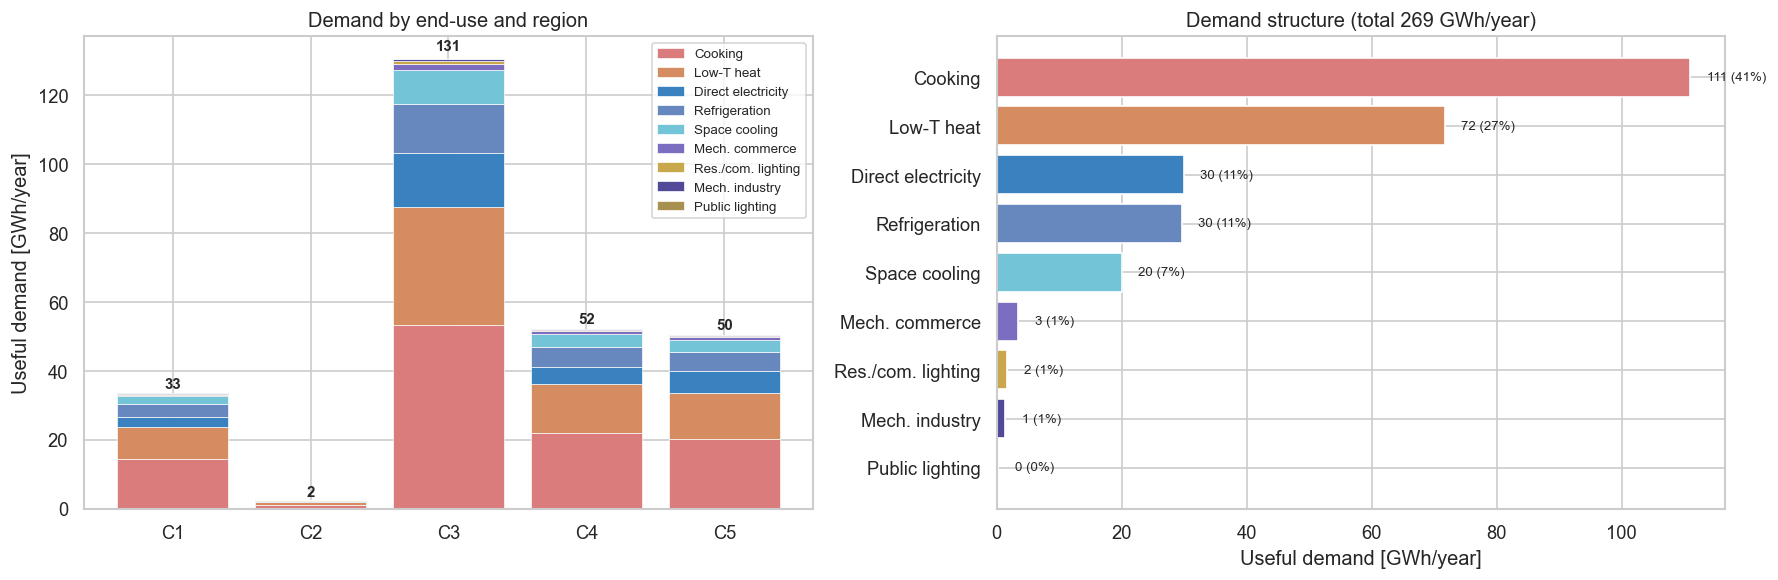

Useful demand by end-use and region [GWh/year]:
         COOKING  ELECTRICITY  SPACE_COOLING  FOOD_PRESERVATION  HEAT_LOW_T_DECEN  LIGHTING_R_C  LIGHTING_P  MECHANICAL_ENERGY_COMM  MECHANICAL_ENERGY_IND
Regions                                                                                                                                                   
C1         14.41         2.80           2.23               3.84              9.30          0.22        0.03                    0.44                   0.18
C2          1.07         0.07           0.19               0.28              0.68          0.02        0.00                    0.03                   0.01
C3         53.22        15.67          10.05              14.16             34.30          0.82        0.10                    1.65                   0.67
C4         22.02         4.84           3.99               5.83             14.14          0.33        0.04                    0.67                   0.26
C5         20.28      

In [83]:
dem = eud_demand(yb, REGIONS)
dem_sorted = dem[dem.sum().sort_values(ascending=False).index]   # dominant uses first

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- (a) demand by end-use and region ---------------------------------------
ax = axes[0]
bottom = np.zeros(len(REGIONS)); x = np.arange(len(REGIONS))
for lay in dem_sorted.columns:
    ax.bar(x, dem_sorted[lay].values, bottom=bottom, label=eud_label(lay),
           color=eud_color(lay), edgecolor='white', linewidth=.4)
    bottom += dem_sorted[lay].values
for xi, tot in zip(x, dem.sum(axis=1).values):
    ax.text(xi, tot + tot*0.01 + 0.3, f'{tot:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[r] for r in REGIONS])
ax.set_ylabel('Useful demand [GWh/year]')
ax.set_title('Demand by end-use and region')
ax.legend(fontsize=8, loc='upper right')

# -- (b) relative structure (share per use, all regions) --------------------
ax = axes[1]
shares = dem.sum().sort_values(ascending=True)
ax.barh(range(len(shares)), shares.values, color=[eud_color(l) for l in shares.index], edgecolor='white')
ax.set_yticks(range(len(shares))); ax.set_yticklabels([eud_label(l) for l in shares.index])
tot = shares.sum()
for i, v in enumerate(shares.values):
    ax.text(v + tot*0.01, i, f'{v:.0f} ({v/tot*100:.0f}%)', va='center', fontsize=8)
ax.set_xlabel('Useful demand [GWh/year]')
ax.set_title(f'Demand structure (total {tot:.0f} GWh/year)')
plt.tight_layout(); plt.show()

print('Useful demand by end-use and region [GWh/year]:')
print(dem.round(2).to_string())

---
## 3. Autonomy & import dependence

A central question for an **isolated** region: what share of energy is produced locally vs imported from outside (electricity from Brazil/SIN, diesel, LPG...)? Electricity imports and imported fossil resources (`Resources.csv`) are combined here.


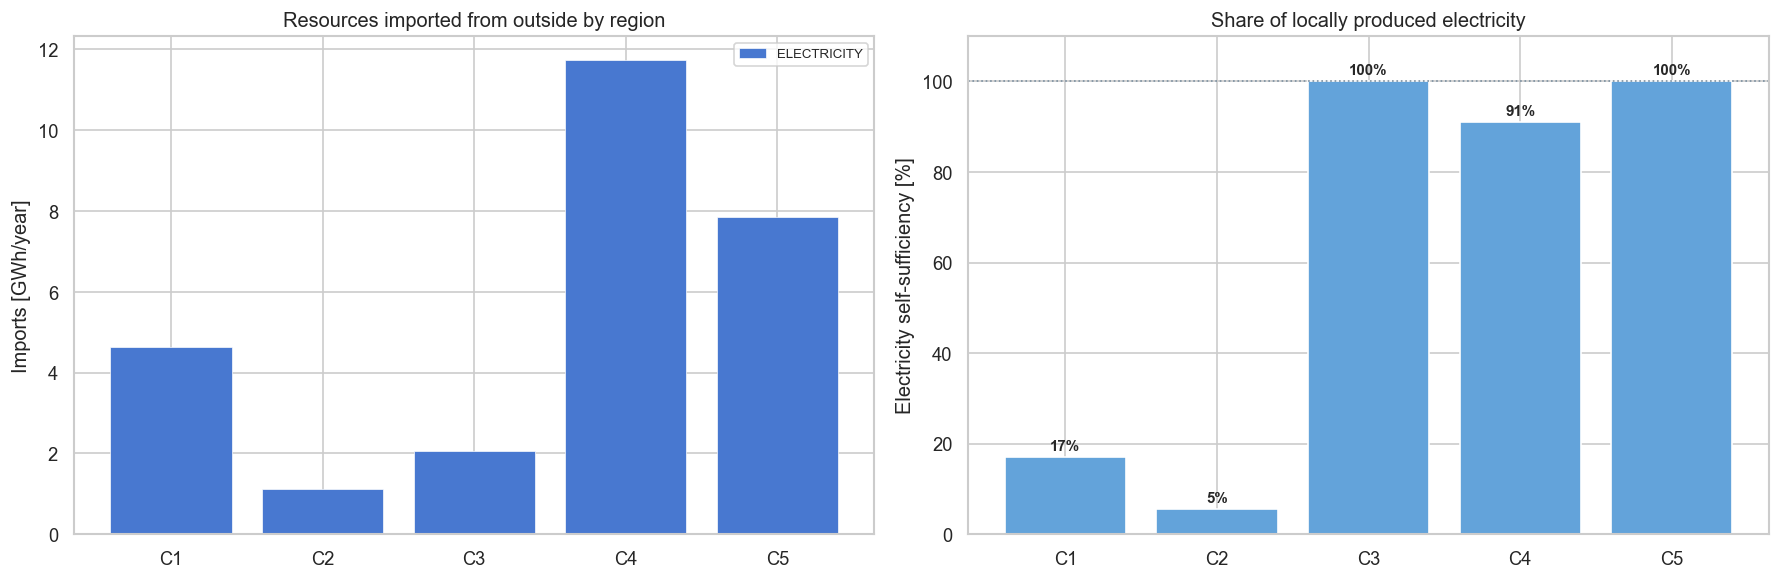

Imports by resource and region [GWh/year]:
Resources  ELECTRICITY
Regions               
C1                4.62
C2                1.11
C3                2.06
C4               11.74
C5                7.84


In [84]:
r = res_reg[res_reg['Regions'].isin(REGIONS)].copy()
imp = r[r['R_year_import'] > EPS].pivot_table(index='Regions', columns='Resources',
        values='R_year_import', aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- (a) resource imports by region -----------------------------------------
ax = axes[0]
imp_s = imp[imp.sum().sort_values(ascending=False).index] if not imp.empty else imp
bottom = np.zeros(len(REGIONS)); x = np.arange(len(REGIONS))
palette = sns.color_palette('muted', max(len(imp_s.columns), 1))
for c, col in zip(imp_s.columns, palette):
    ax.bar(x, imp_s[c].values, bottom=bottom, label=c, color=col, edgecolor='white', linewidth=.4)
    bottom += imp_s[c].values
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[rr] for rr in REGIONS])
ax.set_ylabel('Imports [GWh/year]')
ax.set_title('Resources imported from outside by region')
ax.legend(fontsize=8)

# -- (b) electricity self-sufficiency rate by region ------------------------
ax = axes[1]
es = elec_supply(yb, REGIONS)
loc = es[~es['Elements'].isin(IMPORT_ELEC)].groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
imp_el = es[es['Elements'].isin(IMPORT_ELEC)].groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
tot_el = (loc + imp_el).replace(0, np.nan)
auto = (loc / tot_el * 100).fillna(0)
bars = ax.bar(x, auto.values, color="#63A3DA", edgecolor='white')
for b, v in zip(bars, auto.values):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax.axhline(100, color='#7B8FA0', ls=':', lw=1)
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[rr] for rr in REGIONS])
ax.set_ylabel('Electricity self-sufficiency [%]'); ax.set_ylim(0, 110)
ax.set_title('Share of locally produced electricity')
plt.tight_layout(); plt.show()

print('Imports by resource and region [GWh/year]:')
print((imp.round(2).to_string() if not imp.empty else '  no imports'))

---
## 4. Carbon footprint (GWP)

- **GWP_constr**: equipment manufacturing emissions
- **GWP_op**: operational emissions (combustion, processes)
- **CO2_net**: net balance

Intensity reported in **g CO2/kWh** of electricity produced.


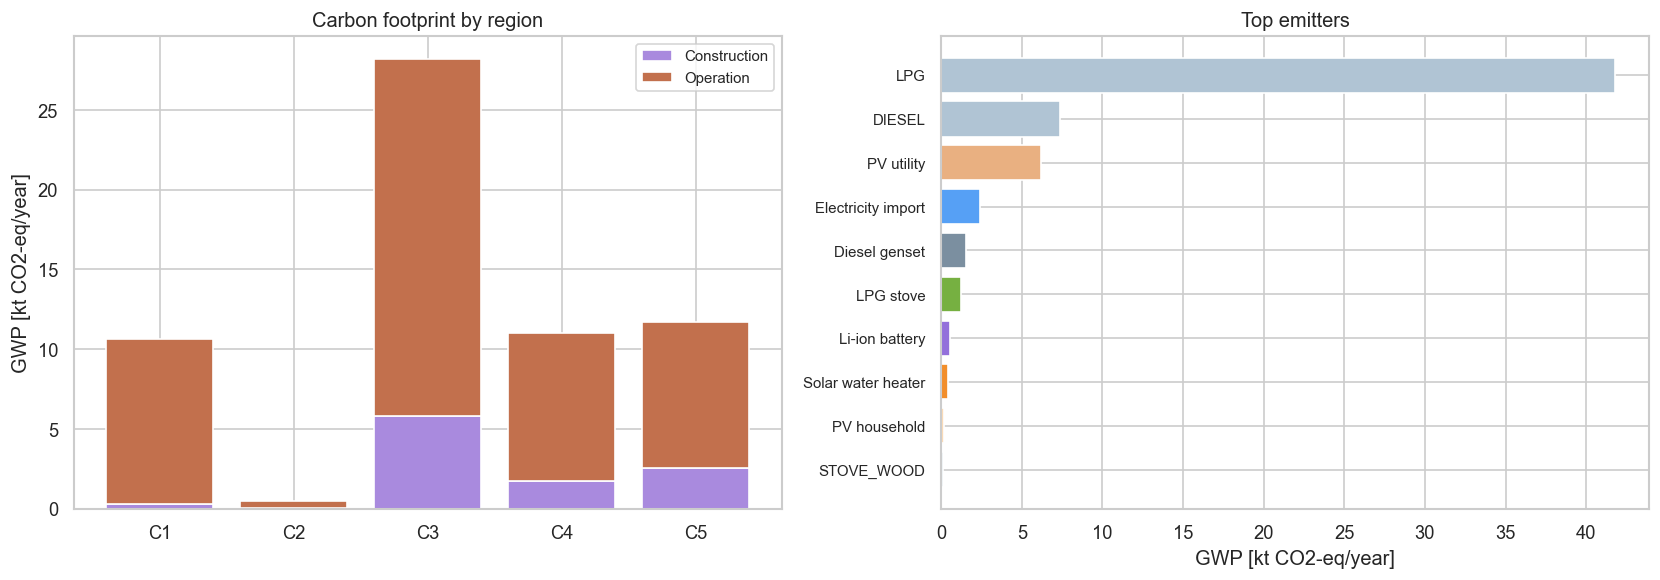

Total operational GWP  : 51.54 kt CO2-eq/year
Electricity intensity  : 325.2 g CO2/kWh produced


In [85]:
g = gwp_reg[gwp_reg['Regions'].isin(REGIONS)].copy()
for col in ['GWP_constr', 'GWP_op', 'CO2_net']:
    g[col] = g[col].fillna(0)
by_reg = g.groupby('Regions')[['GWP_constr', 'GWP_op']].sum().reindex(REGIONS).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- (a) GWP construction vs operation by region ----------------------------
ax = axes[0]
x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
for col in ['GWP_constr', 'GWP_op']:
    color, lab = GWP_COLORS[col], GWP_LABELS[col]
    ax.bar(x, by_reg[col].values, bottom=bottom, color=color, label=lab, edgecolor='white')
    bottom += by_reg[col].values
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('GWP [kt CO2-eq/year]'); ax.set_title('Carbon footprint by region'); ax.legend(fontsize=9)

# -- (b) top emitters -------------------------------------------------------
ax = axes[1]
g['tot'] = g['GWP_constr'] + g['GWP_op']
top = g.groupby('Elements')['tot'].sum().sort_values(ascending=False).head(10)
top = top[top > EPS]
if len(top):
    ax.barh(range(len(top)), top.values[::-1], color=[get_color(t) for t in top.index[::-1]], edgecolor='white')
    ax.set_yticks(range(len(top))); ax.set_yticklabels([get_label(t) for t in top.index[::-1]], fontsize=9)
    ax.set_xlabel('GWP [kt CO2-eq/year]'); ax.set_title('Top emitters')
else:
    ax.text(0.5, 0.5, 'Negligible emissions', ha='center', va='center')
plt.tight_layout(); plt.show()

elec_total = elec_supply(yb, REGIONS)['val'].sum()
co2_op = g['GWP_op'].sum()
print(f'Total operational GWP  : {co2_op:.2f} kt CO2-eq/year')
print(f'Electricity intensity  : {co2_op/elec_total*1000:.1f} g CO2/kWh produced')

---
## 5. Storage

Deployed storage assets (capacity `F`, annual cycled energy) and average **state-of-charge profile** over the day (Li-ion battery).


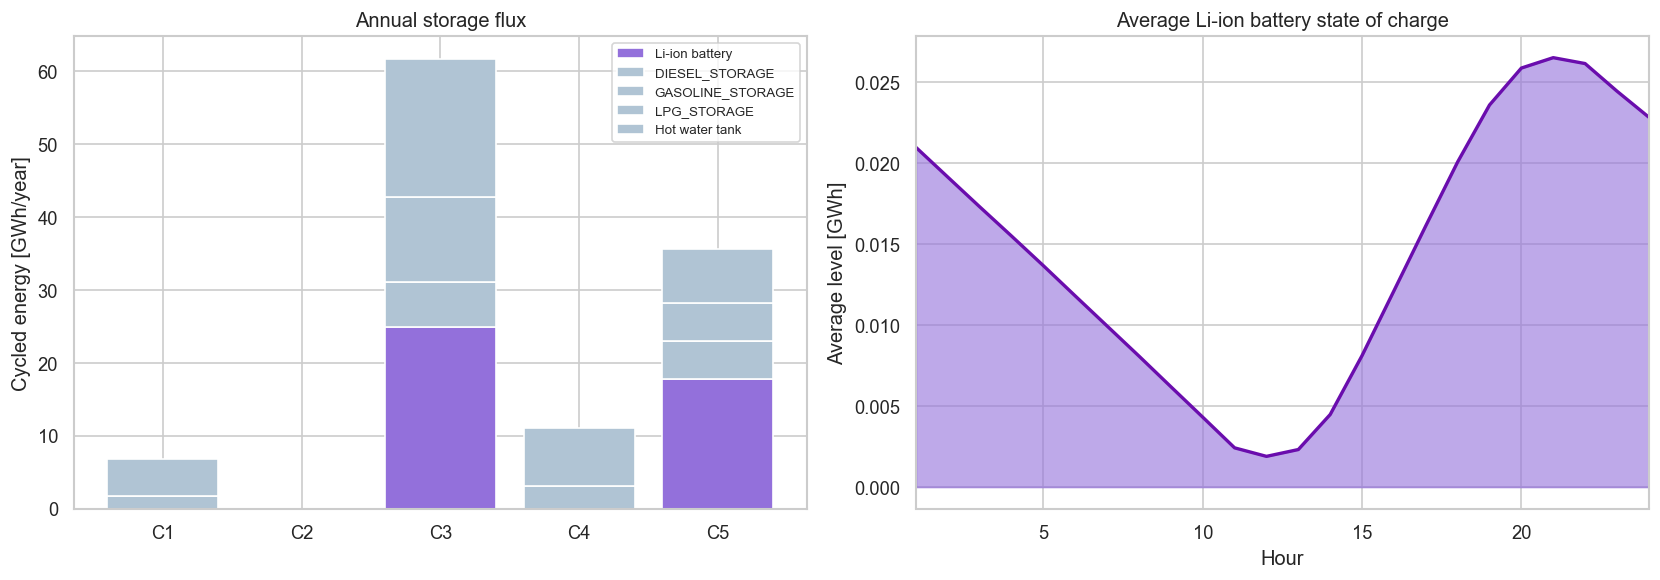

Active storage assets:
Regions       Technologies      F  Year_energy_flux  Losses
     C1 TS_DEC_DIRECT_ELEC    NaN             5.060     NaN
     C1     DIESEL_STORAGE  3.961             1.732     NaN
     C1   GASOLINE_STORAGE  3.681               NaN     NaN
     C3            BATT_LI    NaN            24.881  -2.767
     C3 TS_DEC_DIRECT_ELEC    NaN            18.934  -2.017
     C3     DIESEL_STORAGE 19.288             6.189     NaN
     C3   GASOLINE_STORAGE 17.859               NaN     NaN
     C3        LPG_STORAGE  5.212            11.704     NaN
     C4 TS_DEC_DIRECT_ELEC    NaN             7.886     NaN
     C4     DIESEL_STORAGE  7.558               NaN     NaN
     C4   GASOLINE_STORAGE  7.010               NaN     NaN
     C4        LPG_STORAGE  1.724             3.115     NaN
     C5            BATT_LI    NaN            17.726  -1.981
     C5 TS_DEC_DIRECT_ELEC    NaN             7.318     NaN
     C5     DIESEL_STORAGE  7.474             5.196     NaN
     C5   GASOLIN

In [86]:
s = sto_reg[sto_reg['Regions'].isin(REGIONS)].copy()
s_act = s[s[['F', 'Year_energy_flux']].abs().max(axis=1) > EPS]

if s_act.empty:
    print('No active storage asset.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # -- (a) energy cycled by region / technology ---------------------------
    ax = axes[0]
    piv = s_act.pivot_table(index='Regions', columns='Technologies', values='Year_energy_flux',
                            aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)
    x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
    for tech in piv.columns:
        ax.bar(x, piv[tech].values, bottom=bottom, label=get_label(tech), color=get_color(tech), edgecolor='white')
        bottom += piv[tech].values
    ax.set_xticks(x); ax.set_xticklabels(REGIONS)
    ax.set_ylabel('Cycled energy [GWh/year]'); ax.set_title('Annual storage flux'); ax.legend(fontsize=8)

    # -- (b) average state-of-charge profile (Storage_level) ---------------
    ax = axes[1]
    try:
        sl = pd.read_csv(HOURLY / 'Storage_level.csv', sep=';')
        sl['Storage_level'] = pd.to_numeric(sl['Storage_level'], errors='coerce').fillna(0)
        batt = sl[sl['Storage_tech'] == 'BATT_LI']
        if batt['Storage_level'].abs().sum() > EPS:
            batt = batt.copy(); batt['hour'] = (batt['Periods'] - 1) % 24 + 1
            prof = batt.groupby('hour')['Storage_level'].mean()
            ax.fill_between(prof.index, prof.values, color='#9370DB', alpha=.6)
            ax.plot(prof.index, prof.values, color='#6A0DAD', lw=2)
            ax.set_xlabel('Hour'); ax.set_ylabel('Average level [GWh]')
            ax.set_title('Average Li-ion battery state of charge'); ax.set_xlim(1, 24)
        else:
            ax.text(0.5, 0.5, 'Li-ion battery inactive', ha='center', va='center')
    except FileNotFoundError:
        ax.text(0.5, 0.5, 'Storage_level.csv not found', ha='center', va='center')
    plt.tight_layout(); plt.show()

    print('Active storage assets:')
    print(s_act[['Regions', 'Technologies', 'F', 'Year_energy_flux', 'Losses']].round(3).to_string(index=False))

---
## 6. Curtailment & flexibility

Available renewable energy that is **not used**. Low curtailment indicates well-sized flexibility (storage); high curtailment signals poorly valorised solar surplus.


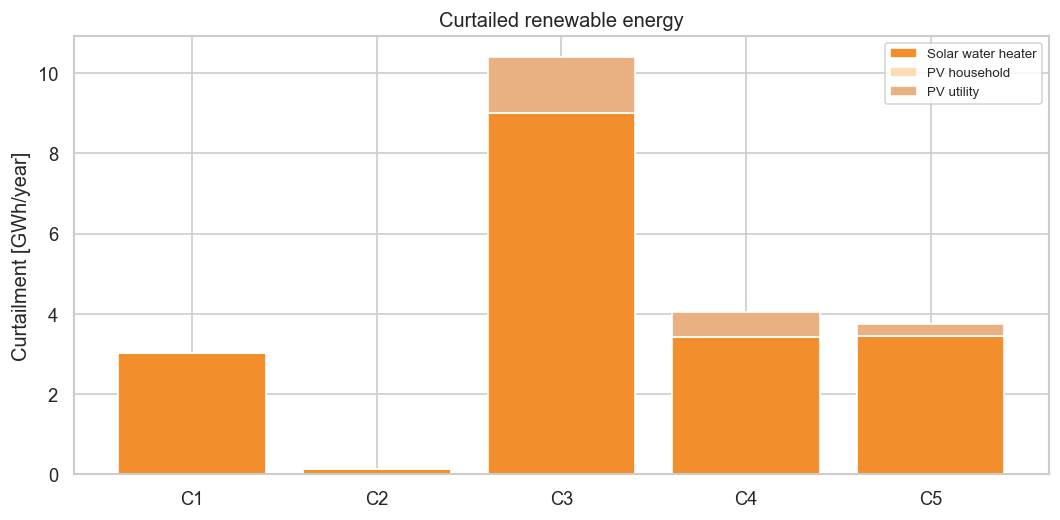

Curtailment total : 21.335 GWh/year
Overall rate      : 13.60 % of renewable potential
Regions Technologies   Curt
     C1   PV_UTILITY 0.0004
     C1        PV_HS 0.0000
     C1    DEC_SOLAR 3.0273
     C2   PV_UTILITY 0.0004
     C2    DEC_SOLAR 0.1256
     C2        PV_HS 0.0000
     C3    DEC_SOLAR 8.9969
     C3        PV_HS 0.0000
     C3   PV_UTILITY 1.4072
     C4        PV_HS 0.0000
     C4    DEC_SOLAR 3.4220
     C4   PV_UTILITY 0.6121
     C5        PV_HS 0.0000
     C5   PV_UTILITY 0.2878
     C5    DEC_SOLAR 3.4551


In [87]:
cu = curt_reg[curt_reg['Regions'].isin(REGIONS)].copy()
cu = cu[cu['Curt'] > EPS]
es = elec_supply(yb, REGIONS)

if cu.empty:
    print('OK Curtailment negligible - all renewable production is valorised.')
else:
    piv = cu.pivot_table(index='Regions', columns='Technologies', values='Curt', aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
    for tech in piv.columns:
        ax.bar(x, piv[tech].values, bottom=bottom, label=get_label(tech), color=get_color(tech), edgecolor='white')
        bottom += piv[tech].values
    ax.set_xticks(x); ax.set_xticklabels(REGIONS)
    ax.set_ylabel('Curtailment [GWh/year]'); ax.set_title('Curtailed renewable energy'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    prod_renew = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()
    tot_curt = cu['Curt'].sum()
    print(f'Curtailment total : {tot_curt:.3f} GWh/year')
    print(f'Overall rate      : {tot_curt/(tot_curt+prod_renew)*100:.2f} % of renewable potential')
    print(cu[['Regions', 'Technologies', 'Curt']].round(4).to_string(index=False))

---
## 7. Inter-regional exchanges

Annual flows exchanged between cells (power lines, fuel transport). Reveals regional specialisation and potential hub roles.


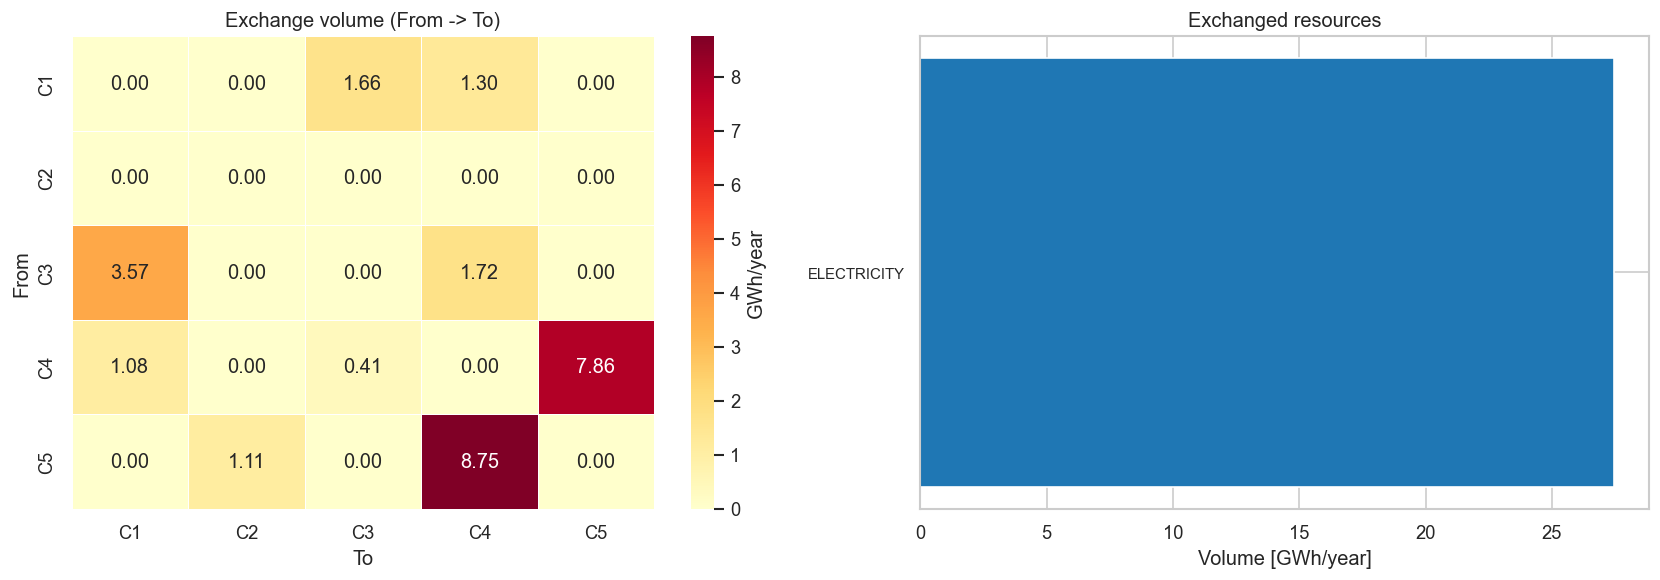

From To   Resources  Exchanges_year
  C1 C3 ELECTRICITY           1.664
  C1 C4 ELECTRICITY           1.301
  C3 C1 ELECTRICITY           3.572
  C3 C4 ELECTRICITY           1.719
  C4 C1 ELECTRICITY           1.084
  C4 C3 ELECTRICITY           0.410
  C4 C5 ELECTRICITY           7.857
  C5 C2 ELECTRICITY           1.107
  C5 C4 ELECTRICITY           8.750


In [88]:
e = exch_reg.copy()
e['Exchanges_year'] = e['Exchanges_year'].fillna(0)
cross = e[(e['From'].isin(REGIONS)) & (e['To'].isin(REGIONS)) &
          (e['From'] != e['To']) & (e['Exchanges_year'].abs() > EPS)]

if cross.empty:
    print('No significant inter-regional exchange (near-isolated cells).')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    mat = cross.groupby(['From', 'To'])['Exchanges_year'].sum().unstack(fill_value=0).reindex(index=REGIONS, columns=REGIONS, fill_value=0)
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=.5, cbar_kws={'label': 'GWh/year'})
    ax.set_title('Exchange volume (From -> To)'); ax.set_xlabel('To'); ax.set_ylabel('From')
    ax = axes[1]
    byres = cross.groupby('Resources')['Exchanges_year'].sum().sort_values(ascending=True)
    byres = byres[byres.abs() > EPS]
    ax.barh(range(len(byres)), byres.values, color=sns.color_palette('tab10', len(byres)))
    ax.set_yticks(range(len(byres))); ax.set_yticklabels(byres.index, fontsize=9)
    ax.set_xlabel('Volume [GWh/year]'); ax.set_title('Exchanged resources')
    plt.tight_layout(); plt.show()
    print(cross[['From', 'To', 'Resources', 'Exchanges_year']].round(3).to_string(index=False))

---
## 8. Hourly profiles - electric dispatch vs demand

EnergyScope represents the year with **16 typical days**. Here, **production** (stacked by technology) and **electricity demand** (black curve) are overlaid to visualise how supply follows load, typical day by typical day.


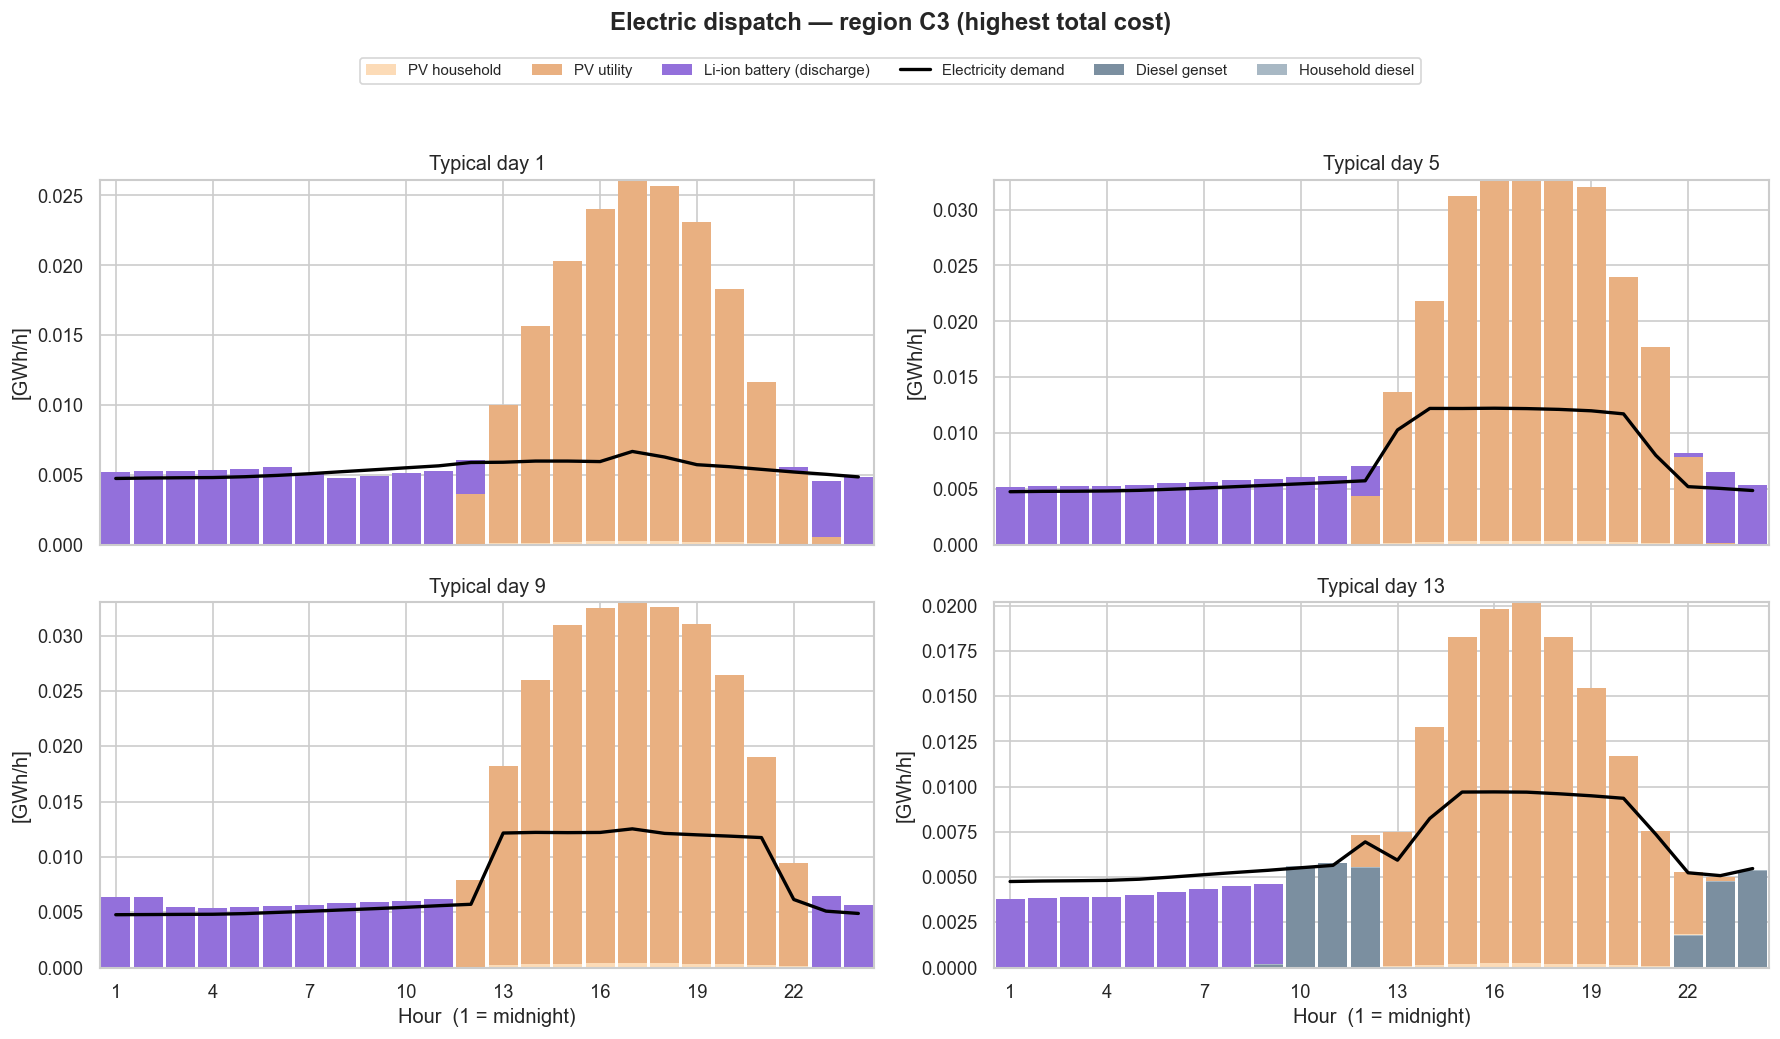

Region : C3  |  Typical days shown : [1, 5, 9, 13]
Generator techs in year balance : ['GENSET_DIESEL', 'HS_DIESEL', 'PV_HS', 'PV_UTILITY']
Active electricity consumers : ['AGR_MACHINERY_EL', 'ATM_CCS', 'BIOMASS_TO_HVC', 'BOAT_FREIGHT_ELEC', 'BUS_ELEC_PRIVATE', 'BUS_ELEC_PUBLIC', 'CARGO_FUELCELL_LH2', 'CARGO_MOTORCYCLE_ELEC', 'CAR_BEV', 'CAR_PHEV', 'COMM_MACHINERY_EL', 'CONVENTIONAL_BULB', 'CONVENTIONAL_LIGHT', 'DEC_DIRECT_ELEC', 'DEC_ELEC_COLD', 'DEC_HP_ELEC', 'DHN_HP_ELEC', 'FISH_MACHINERY_EL', 'GAS_TO_HVC', 'H2_ELECTROLYSIS', 'H2_TO_JET_FUEL', 'H2_TO_LFO', 'HABER_BOSCH', 'INDUSTRY_CCS', 'IND_DIRECT_ELEC', 'IND_ELEC_COLD', 'IND_MACHINERY_EL', 'LED_BULB', 'LED_LIGHT', 'MIN_MACHINERY_EL', 'MOTORCYCLE_ELEC_PRIVATE', 'MOTORCYCLE_ELEC_PUBLIC', 'OIL_TO_HVC', 'PICKUP_TRUCK_ELEC_PRIVATE', 'PICKUP_TRUCK_ELEC_PUBLIC', 'POWER_TO_JET_FUEL', 'POWER_TO_LFO', 'REFRIGERATOR_EL', 'STOVE_ELEC', 'SUV_ELEC_PRIVATE', 'SUV_ELEC_PUBLIC', 'SYN_METHANOLATION', 'TRACTOR_EL', 'TRAIN_FREIGHT_ELEC', 'TRAIN_PUB', 

In [89]:
# ── Load hourly data ────────────────────────────────────────────────────────
ft = pd.read_csv(HOURLY / 'F_t.csv', sep=';')
ft['F_t'] = pd.to_numeric(ft['F_t'], errors='coerce').fillna(0)

# Storage_power.csv: Storage_out >= 0 (discharge), Storage_in <= 0 (charge)
sp = pd.read_csv(HOURLY / 'Storage_power.csv', sep=';')
sp['Storage_out'] = pd.to_numeric(sp['Storage_out'], errors='coerce').fillna(0)
sp['Storage_in']  = pd.to_numeric(sp['Storage_in'],  errors='coerce').fillna(0)

# R_t_exterior.csv: hourly resource imports from outside the cell
rt_ext = pd.read_csv(HOURLY / 'R_t_exterior.csv', sep=';')
rt_ext['R_t_exterior'] = pd.to_numeric(rt_ext['R_t_exterior'], errors='coerce').fillna(0)

# Layers_in_out: electricity consumers (coef < 0) → |coef| used to weight F_t
lio = pd.read_csv(DATA_DIR / '00_INDEP' / 'Layers_in_out.csv', sep=';', index_col=0)
elec_consumer_coef = lio[lio['ELECTRICITY'] < 0]['ELECTRICITY'].abs()
active_consumers = elec_consumer_coef.index.intersection(ft['Technologies'].unique())

REGION_ANALYSE = total_cost.sort_values('TotalCost', ascending=False).iloc[0]['Regions']
HOURS = list(range(1, 25))

# Generators that produce electricity (from year balance, no imports, no storage)
gen_techs = set(elec_supply(yb, REGIONS)['Elements']) - IMPORT_ELEC

diesel_tds = sorted(
    ft[(ft['Regions'] == REGION_ANALYSE) & (ft['Technologies'] == 'GENSET_DIESEL') & (ft['F_t'] > EPS)]
    ['Typical_days'].unique().tolist()
)
TD_SHOW = [1, 5, 9, 13]
if diesel_tds and not any(td in diesel_tds for td in TD_SHOW):
    TD_SHOW[1] = diesel_tds[0]

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
all_handles = {}

for ax, td in zip(axes.ravel(), TD_SHOW):
    # ── Generators ──────────────────────────────────────────────────────────
    mask_gen = ((ft['Regions'] == REGION_ANALYSE) & (ft['Typical_days'] == td)
                & ft['Technologies'].isin(gen_techs) & (ft['F_t'] > EPS))
    gen = (ft[mask_gen]
           .pivot_table(index='Hours', columns='Technologies', values='F_t', aggfunc='sum', fill_value=0)
           .reindex(HOURS, fill_value=0))

    # ── SIN electricity import (R_t_exterior, resource ELECTRICITY) ──────────
    elec_imp = (rt_ext[(rt_ext['Regions'] == REGION_ANALYSE) & (rt_ext['Typical_days'] == td)
                        & (rt_ext['Resources'] == 'ELECTRICITY')]
                .set_index('Hours')['R_t_exterior']
                .reindex(HOURS, fill_value=0))

    # ── Li-ion battery discharge ──────────────────────────────────────────────
    batt = (sp[(sp['Regions'] == REGION_ANALYSE) & (sp['Typical_days'] == td)
               & (sp['Storage_tech'] == 'BATT_LI')]
            .set_index('Hours'))
    batt_dis = batt['Storage_out'].reindex(HOURS, fill_value=0)

    # ── Stacked bars (generators → SIN import → battery discharge) ───────────
    bottom = np.zeros(len(HOURS))
    for tech in gen.columns:
        h = ax.bar(HOURS, gen[tech].values, bottom=bottom, color=get_color(tech), width=0.9, edgecolor='none')
        bottom += gen[tech].values
        all_handles.setdefault(get_label(tech), h[0])

    if elec_imp.sum() > EPS:
        h = ax.bar(HOURS, elec_imp.values, bottom=bottom, color=get_color('ELECTRICITY'), width=0.9, edgecolor='none')
        bottom += elec_imp.values
        all_handles.setdefault('Electricity import (SIN)', h[0])

    if batt_dis.sum() > EPS:
        h = ax.bar(HOURS, batt_dis.values, bottom=bottom, color=get_color('BATT_LI'), width=0.9, edgecolor='none')
        bottom += batt_dis.values
        all_handles.setdefault('Li-ion battery (discharge)', h[0])

    # ── Exogenous demand line (sum of consumer F_t × |Layers_in_out| coef) ───
    # Independent of supply — verifies supply ≥ demand at every hour.
    # Gap between bars and line = battery charging at that hour (excess PV stored).
    mask_dem = ((ft['Regions'] == REGION_ANALYSE) & (ft['Typical_days'] == td)
                & ft['Technologies'].isin(active_consumers))
    dem_df = ft[mask_dem].copy()
    dem_df['contrib'] = dem_df['F_t'] * dem_df['Technologies'].map(elec_consumer_coef.to_dict())
    demand = dem_df.groupby('Hours')['contrib'].sum().reindex(HOURS, fill_value=0)
    line, = ax.plot(HOURS, demand.values, color='black', lw=2)
    all_handles.setdefault('Electricity demand', line)

    ax.set_title(f'Typical day {td}')
    ax.set_xlim(0.5, 24.5)
    ax.set_xticks(range(1, 25, 3))
    ax.set_ylabel('[GWh/h]')

for ax in axes[1, :]:
    ax.set_xlabel('Hour  (1 = midnight)')

fig.legend(all_handles.values(), all_handles.keys(),
           loc='upper center', ncol=min(6, len(all_handles)), fontsize=9, bbox_to_anchor=(0.5, 1.04))
plt.suptitle(f'Electric dispatch — region {REGION_ANALYSE} (highest total cost)', y=1.08, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Region : {REGION_ANALYSE}  |  Typical days shown : {TD_SHOW}')
print(f'Generator techs in year balance : {sorted(gen_techs)}')
print(f'Active electricity consumers : {sorted(active_consumers)}')
if diesel_tds:
    print(f'GENSET_DIESEL active in TDs : {diesel_tds}')

---
## 11. Summary

Summary table for the scenario and reading guide for the thesis write-up.

In [90]:
es = elec_supply(yb, REGIONS)
dem = eud_demand(yb, REGIONS)
elec_total = es['val'].sum()
elec_renew = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()
elec_imp = es[es['Elements'].isin(IMPORT_ELEC)]['val'].sum()

line = '=' * 64
print(line); print(f'  SUMMARY - {SCENARIO}'); print(line)
print(f'  Total system cost          : {total_cost["TotalCost"].sum():>8.2f} M€/year')
print(f'  Useful demand served       : {dem.values.sum():>8.1f} GWh/year')
print(f'  Average cost               : {total_cost["TotalCost"].sum()*1000/dem.values.sum():>8.1f} EUR/MWh useful')
print(f'  Electricity production     : {elec_total:>8.1f} GWh/year')
print(f'     of which local renewable: {elec_renew/elec_total*100:>8.1f} %')
print(f'     of which imported       : {elec_imp/elec_total*100:>8.1f} %')
print(f'  CO2 emissions (op.)        : {gwp_reg["GWP_op"].fillna(0).sum():>8.2f} kt/year')
print('-' * 64)
print('  Dominant use by region   :')
for rg in REGIONS:
    top_use = dem.loc[rg].idxmax()
    print(f'    {rg} : demand {dem.loc[rg].sum():6.1f} GWh  .  top use = {eud_label(top_use)} ({dem.loc[rg].max():.1f} GWh)')
print(line)

print('''
READING GUIDE FOR THE THESIS
  1. Demand      : which uses dominate (cooking? refrigeration?) and why
                    (Amazonian climate, sufficiency vs reality)?
  2. Supply      : why does PV dominate? what role for diesel / imports?
  3. Autonomy    : which regions depend most on external supply?
  4. Cost        : why is the most expensive region the most expensive
                    (demand, resource, isolation)?
  5. Robustness  : which technologies appear in ALL scenarios (no-regret) vs
                    sensitive to demand? -> see section 10, which compares
                    universal sufficiency to current system, supply transition
                    and universal access.''')

  SUMMARY - norte_amazonia_sufficiency_2025
  Total system cost          :    31.85 M€/year
  Useful demand served       :    268.9 GWh/year
  Average cost               :    118.5 EUR/MWh useful
  Electricity production     :    158.5 GWh/year
     of which local renewable:     85.5 %
     of which imported       :     10.6 %
  CO2 emissions (op.)        :    51.54 kt/year
----------------------------------------------------------------
  Dominant use by region   :
    C1 : demand   33.5 GWh  .  top use = Cooking (14.4 GWh)
    C2 : demand    2.3 GWh  .  top use = Cooking (1.1 GWh)
    C3 : demand  130.6 GWh  .  top use = Cooking (53.2 GWh)
    C4 : demand   52.1 GWh  .  top use = Cooking (22.0 GWh)
    C5 : demand   50.3 GWh  .  top use = Cooking (20.3 GWh)

READING GUIDE FOR THE THESIS
  1. Demand      : which uses dominate (cooking? refrigeration?) and why
                    (Amazonian climate, sufficiency vs reality)?
  2. Supply      : why does PV dominate? what role for diesel 

---
## 10. Scenario comparison - Universal sufficiency vs Current system vs Supply transition vs Universal access

Comparison of **`norte_amazonia_sufficiency_2025`** (universal sufficiency, reference), **`norte_amazonia_reality_2025`** (current system), **`norte_amazonia_reality_2025_phase2`** (supply transition, centralised grid reinforcement) and **`norte_amazonia_reality_access_2025`** (universal access) on key indicators: demand, electricity mix, costs, carbon footprint.

All deltas are expressed **relative to Universal sufficiency**.


In [91]:
# -- Load every scenario of the comparison set -------------------------------
DS = {lab: load_scenario(ROOT / scen / 'outputs') for lab, scen in COMPARE.items()}

def kpis(D):
    yb_  = D['yb']
    tc   = D['total_cost']; tc = tc[tc['Regions'].isin(REGIONS)]
    es_  = elec_supply(yb_, REGIONS)
    dem_ = eud_demand(yb_, REGIONS)
    elec_tot   = es_['val'].sum()
    elec_renew = es_[es_['Elements'].isin(RENEW_ELEC)]['val'].sum()
    elec_imp   = es_[es_['Elements'].isin(IMPORT_ELEC)]['val'].sum()
    cost_tot   = tc['TotalCost'].sum()
    demand_tot = dem_.values.sum()
    co2_op     = pd.to_numeric(D['gwp']['GWP_op'], errors='coerce').fillna(0).sum()
    n_tech     = (D['assets'][D['assets']['F'] > EPS])['Technologies'].nunique()
    return {
        'Total cost (M€/year)':     round(cost_tot, 2),
        'Useful demand (GWh/year)': round(demand_tot, 1),
        'Average cost (€/MWh)':     round(cost_tot * 1000 / demand_tot, 1),
        'Elec. prod. (GWh/year)':   round(elec_tot, 1),
        'Renewable share (%)':      round(elec_renew / elec_tot * 100, 1),
        'Elec. import share (%)':   round(elec_imp / elec_tot * 100, 1),
        'GWP op. (kt CO2/year)':    round(co2_op, 2),
        'Deployed techs':           n_tech,
    }

comp = pd.DataFrame({lab: kpis(D) for lab, D in DS.items()})[list(COMPARE)]
for lab in COMPARE:
    if lab != SCEN_REF:
        comp[f'{lab} vs ref (%)'] = ((comp[lab] - comp[SCEN_REF]) / comp[SCEN_REF].abs() * 100).round(1)

print('=' * 96)
print(f'  COMPARISON TABLE  -  reference = {SCEN_REF}')
print('=' * 96)
print(comp.to_string())
print('=' * 96)

  COMPARISON TABLE  -  reference = Universal sufficiency
                          Universal sufficiency  Current system  Supply transition  Universal access  Access transition  Current system vs ref (%)  Supply transition vs ref (%)  Universal access vs ref (%)  Access transition vs ref (%)
Total cost (M€/year)                      31.85           66.65              42.29             69.73              47.74                      109.3                          32.8                        118.9                          49.9
Useful demand (GWh/year)                 268.90          327.20             333.10            362.90             367.20                       21.7                          23.9                         35.0                          36.6
Average cost (€/MWh)                     118.50          203.70             126.90            192.20             130.00                       71.9                           7.1                         62.2                           9.7

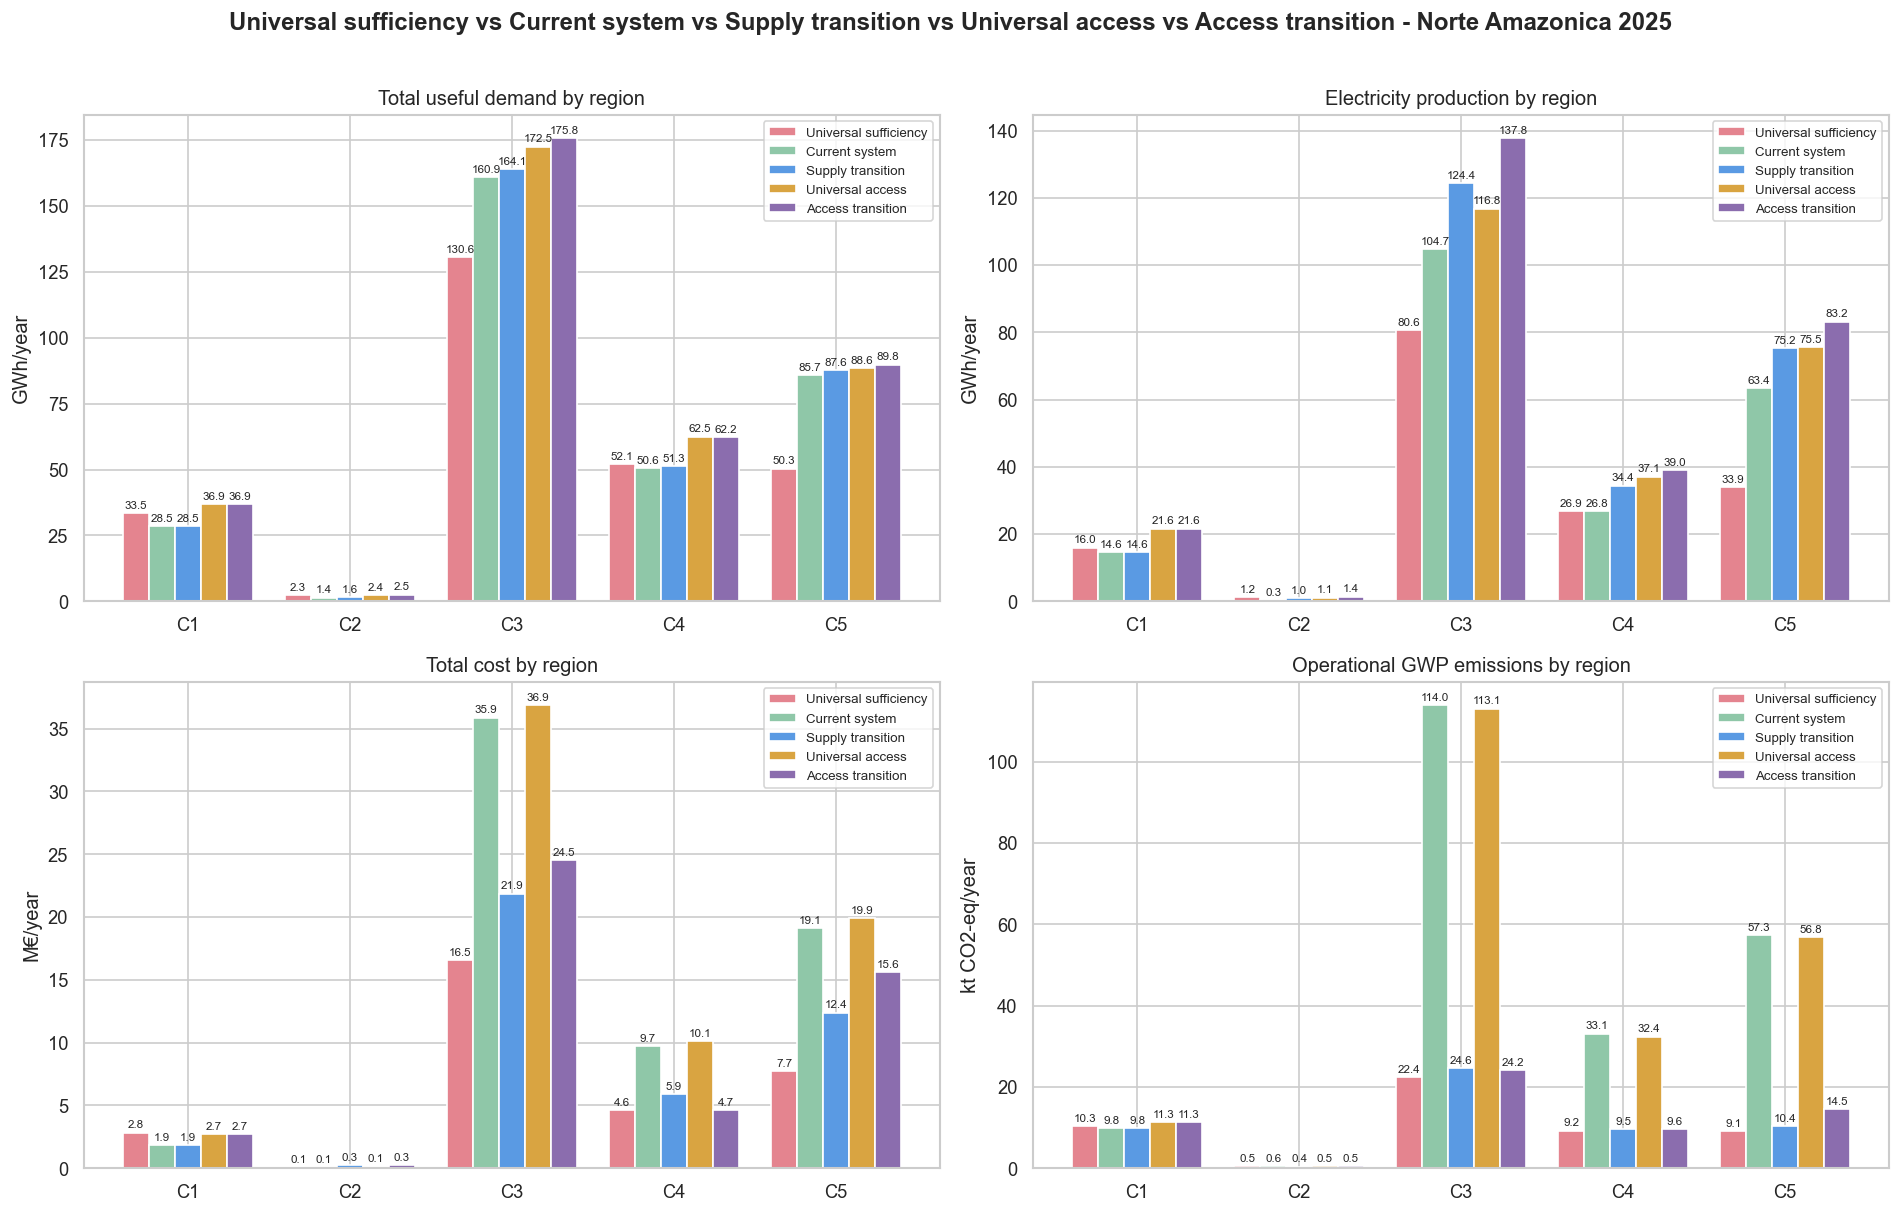

In [92]:
# -- Comparison charts by region --------------------------------------------
def by_region(D, what):
    if what == 'demand':
        return eud_demand(D['yb'], REGIONS).sum(axis=1).reindex(REGIONS).fillna(0)
    if what == 'elec':
        return elec_supply(D['yb'], REGIONS).groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
    if what == 'cost':
        c = D['cost'][D['cost']['Regions'].isin(REGIONS)]
        return c.groupby('Regions')[['C_inv', 'C_maint', 'C_op']].sum().sum(axis=1).reindex(REGIONS).fillna(0)
    if what == 'gwp':
        g = D['gwp'][D['gwp']['Regions'].isin(REGIONS)]
        return g.groupby('Regions')['GWP_op'].sum().reindex(REGIONS).fillna(0)
    raise ValueError(what)

PANELS = [('demand', 'Total useful demand by region',        'GWh/year'),
          ('elec',   'Electricity production by region',     'GWh/year'),
          ('cost',   'Total cost by region',                 'M€/year'),
          ('gwp',    'Operational GWP emissions by region',  'kt CO2-eq/year')]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = np.arange(len(REGIONS)); n = len(COMPARE); w = 0.8 / n

for ax, (what, title, unit) in zip(axes.ravel(), PANELS):
    vals = {lab: by_region(D, what) for lab, D in DS.items()}
    vmax = max(v.max() for v in vals.values()) or 1
    for k, (lab, v) in enumerate(vals.items()):
        bars = ax.bar(x + (k - (n - 1) / 2) * w, v.values, w,
                      color=SCEN_COLORS[lab], label=lab, edgecolor='white')
        for b, val in zip(bars, v.values):
            ax.text(b.get_x() + b.get_width() / 2, val + vmax * 0.01, f'{val:.1f}',
                    ha='center', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(REGIONS)
    ax.set_ylabel(unit); ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle(' vs '.join(COMPARE) + ' - Norte Amazonica 2025',
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

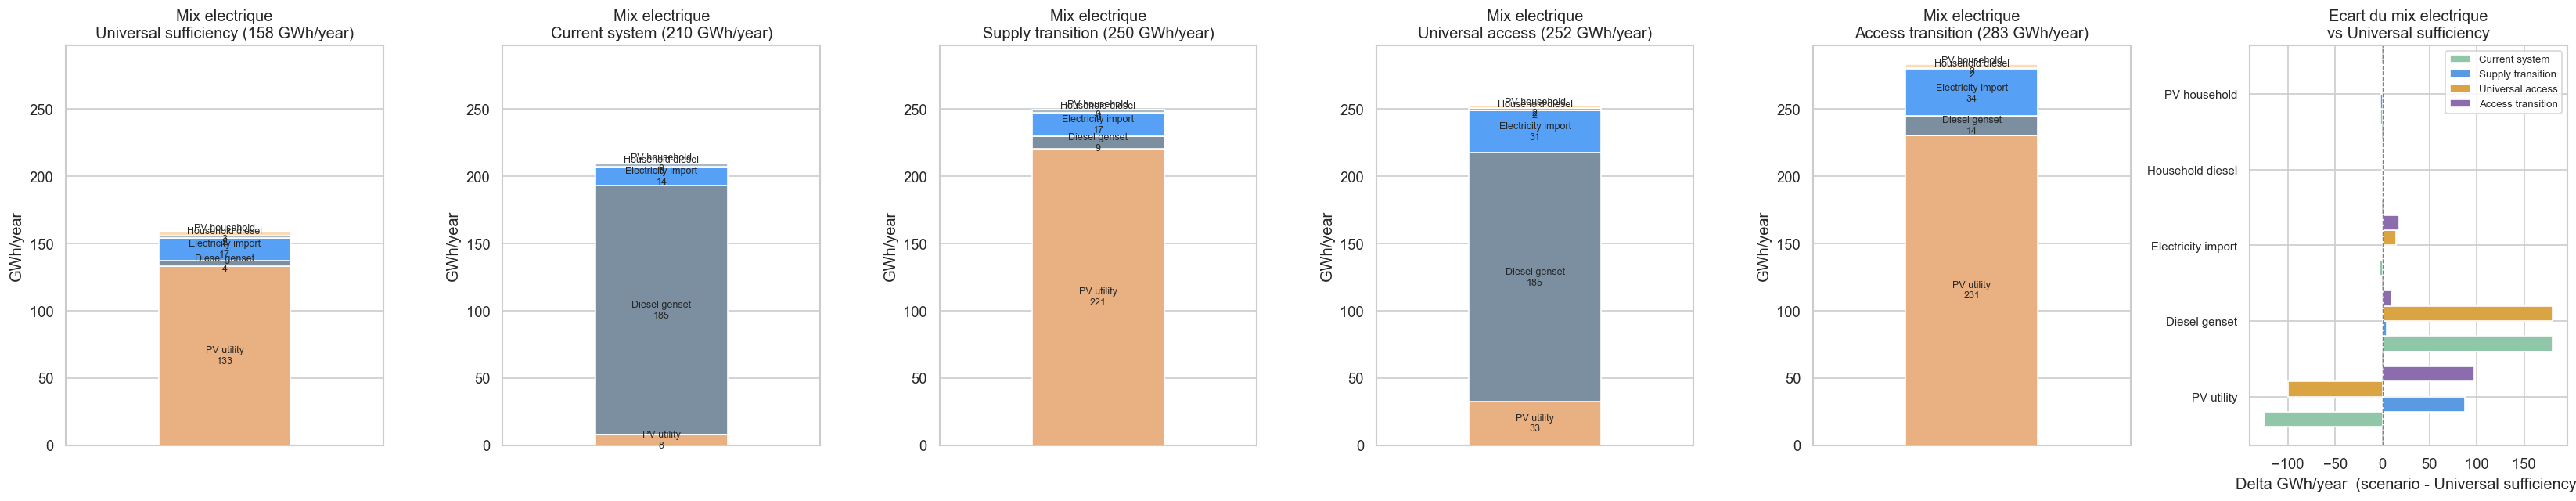

In [93]:
# -- Compared electricity mix (all regions aggregated) ----------------------
mixes = {lab: elec_supply(D['yb'], REGIONS).groupby('Elements')['val'].sum()
         for lab, D in DS.items()}
all_techs = sorted(set().union(*[set(m.index) for m in mixes.values()]),
                   key=lambda t: -sum(m.get(t, 0) for m in mixes.values()))

n = len(COMPARE)
fig, axes = plt.subplots(1, n + 1, figsize=(4.6 * (n + 1), 5.5))

for ax, (lab, mix) in zip(axes[:n], mixes.items()):
    bottom = 0
    for t in all_techs:
        v = mix.get(t, 0)
        if v > EPS:
            ax.bar(0, v, bottom=bottom, color=get_color(t), width=0.5)
            ax.text(0, bottom + v / 2, f'{get_label(t)}\n{v:.0f}',
                    ha='center', va='center', fontsize=7.5)
            bottom += v
    ax.set_xlim(-0.6, 0.6); ax.set_xticks([]); ax.set_ylabel('GWh/year')
    ax.set_title(f'Mix electrique\n{lab} ({mix.sum():.0f} GWh/year)')

ymax = max(ax.get_ylim()[1] for ax in axes[:n])     # shared scale -> panels comparable
for ax in axes[:n]:
    ax.set_ylim(0, ymax)

# -- (d) delta by technology, each scenario against the reference ------------
ax = axes[n]
others  = [lab for lab in COMPARE if lab != SCEN_REF]
techs_d = [t for t in all_techs
           if any(abs(mixes[l].get(t, 0) - mixes[SCEN_REF].get(t, 0)) > EPS for l in others)]
y = np.arange(len(techs_d)); h = 0.8 / len(others)
for k, lab in enumerate(others):
    d = [mixes[lab].get(t, 0) - mixes[SCEN_REF].get(t, 0) for t in techs_d]
    ax.barh(y + (k - (len(others) - 1) / 2) * h, d, h,
            color=SCEN_COLORS[lab], label=lab, edgecolor='white')
ax.set_yticks(y); ax.set_yticklabels([get_label(t) for t in techs_d], fontsize=9)
ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'Delta GWh/year  (scenario - {SCEN_REF})')
ax.set_title(f'Ecart du mix electrique\nvs {SCEN_REF}'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

CRF(10%, 30 years) = 0.10608

  GRID INFRASTRUCTURE  -  extension_capex_EUR  (scenarios: Access transition, Universal access, Universal sufficiency)
  CRF annualisation (10% / 30 years) - consistent with EnergyScope
Region   CAPEX total (M-euro) Annualised CRF (M-euro/yr)
--------------------------------------------------------------
C1                     14.511                      1.539
C2                      1.923                      0.204
C3                     11.802                      1.252
C4                     17.188                      1.823
C5                      0.157                      0.017
--------------------------------------------------------------
TOTAL                  45.582                      4.835


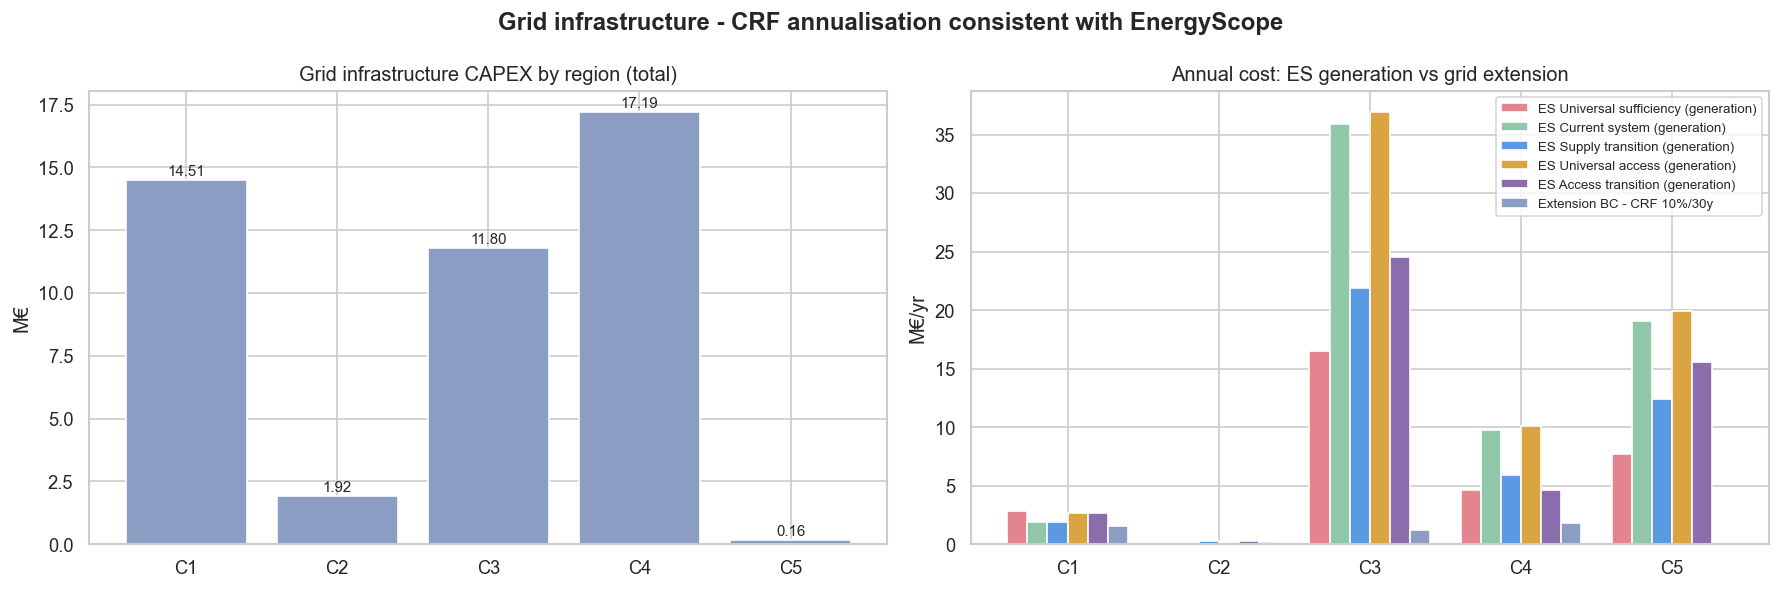


  TOTAL SYSTEM COST SUMMARY  (M-euro/year)
                                        Universal sufficiency           Current system        Supply transition         Universal access        Access transition
---------------------------------------------------------------------------------------------------------------------------------------------------------------
  Generation (EnergyScope/CPLEX)                       31.850                   66.648                   42.286                   69.734                   47.740
  Grid extension BC (CRF 10%/30y)                       4.835                    0.000                    0.000                    4.835                    4.835
---------------------------------------------------------------------------------------------------------------------------------------------------------------
  TOTAL system cost                                    36.686                   66.648                   42.286                   74.569              

In [94]:
# -- Grid infrastructure (extension_capex_EUR) -------------------------------
# Annualised using CRF consistent with EnergyScope (i=10%, n=30 years).
# The BC extension connects dispersed households: it is charged only to the
# scenarios that achieve universal access (GRID_EXT_SCEN); Current system (no
# new connections) -> 0.
# The per-cluster dispersion shares are geographic, so the sufficiency copy of
# the file is used for every scenario - no reality-specific version exists.
I_RATE   = 0.10
LIFETIME = 30
CRF = I_RATE * (1 + I_RATE)**LIFETIME / ((1 + I_RATE)**LIFETIME - 1)

infra = pd.read_csv(DATA / 'sufficiency' / 'share_dispersion_final_BC.csv')
infra = infra[infra['Cluster'].isin(REGIONS)].set_index('Cluster')

capex_bc   = infra['extension_capex_EUR'] / 1e6      # M€ total CAPEX
annualized = capex_bc * CRF                          # M€/yr (CRF)

print(f'CRF({I_RATE:.0%}, {LIFETIME} years) = {CRF:.5f}')
print()
print('=' * 62)
print(f'  GRID INFRASTRUCTURE  -  extension_capex_EUR  (scenarios: {", ".join(sorted(GRID_EXT_SCEN))})')
print(f'  CRF annualisation ({I_RATE:.0%} / {LIFETIME} years) - consistent with EnergyScope')
print('=' * 62)
print(f'{"Region":<8} {"CAPEX total (M-euro)":>20} {"Annualised CRF (M-euro/yr)":>26}')
print('-' * 62)
for rg in REGIONS:
    print(f'{rg:<8} {capex_bc.get(rg, 0):>20.3f} {annualized.get(rg, 0):>26.3f}')
print('-' * 62)
print(f'{"TOTAL":<8} {capex_bc.sum():>20.3f} {annualized.sum():>26.3f}')
print('=' * 62)

# -- Chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(REGIONS))

ax = axes[0]
cap = capex_bc.reindex(REGIONS).fillna(0)
bars = ax.bar(x, cap.values, color='#8B9DC3', edgecolor='white')
for b, v in zip(bars, cap.values):
    ax.text(b.get_x() + b.get_width() / 2, v + cap.max() * 0.01, f'{v:.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('M€'); ax.set_title('Grid infrastructure CAPEX by region (total)')

ax = axes[1]
infra_ann = annualized.reindex(REGIONS).fillna(0)
gen_cost = {lab: by_region(D, 'cost') for lab, D in DS.items()}
n = len(gen_cost) + 1; w = 0.8 / n
for k, (lab, v) in enumerate(gen_cost.items()):
    ax.bar(x + (k - (n - 1) / 2) * w, v.values, w, color=SCEN_COLORS[lab],
           label=f'ES {lab} (generation)', edgecolor='white')
ax.bar(x + (len(gen_cost) - (n - 1) / 2) * w, infra_ann.values, w, color='#8B9DC3',
       label=f'Extension BC - CRF {I_RATE:.0%}/{LIFETIME}y', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('M€/yr'); ax.set_title('Annual cost: ES generation vs grid extension')
ax.legend(fontsize=8)

plt.suptitle('Grid infrastructure - CRF annualisation consistent with EnergyScope', fontweight='bold')
plt.tight_layout(); plt.show()

# -- Corrected summary table (generation + extension) -------------------------
tot_infra_ann = annualized.sum()
rows = {}
for lab, D in DS.items():
    tc = D['total_cost']
    es_cost = tc[tc['Regions'].isin(REGIONS)]['TotalCost'].sum()
    ext     = tot_infra_ann if lab in GRID_EXT_SCEN else 0.0
    rows[lab] = (es_cost, ext, es_cost + ext)

cw = max(len(lab) for lab in rows) + 4
line = '=' * (34 + cw * len(rows))
print(); print(line)
print('  TOTAL SYSTEM COST SUMMARY  (M-euro/year)')
print(line)
print(f'  {"":34s}' + ''.join(f'{lab:>{cw}}' for lab in rows))
print('-' * (34 + cw * len(rows)))
print(f'  {"Generation (EnergyScope/CPLEX)":34s}' + ''.join(f'{v[0]:>{cw}.3f}' for v in rows.values()))
print(f'  {"Grid extension BC (CRF 10%/30y)":34s}' + ''.join(f'{v[1]:>{cw}.3f}' for v in rows.values()))
print('-' * (34 + cw * len(rows)))
print(f'  {"TOTAL system cost":34s}' + ''.join(f'{v[2]:>{cw}.3f}' for v in rows.values()))
print(line)
ref_tot = rows[SCEN_REF][2]
for lab, v in rows.items():
    if lab == SCEN_REF:
        continue
    d = v[2] - ref_tot
    print(f'  Delta  {lab:<16} vs {SCEN_REF} : {d:+.3f} M-euro/year  ({d / ref_tot * 100:+.1f} %)')
print(line)


---
## 11. Chapter 5 figures (thesis)

Nine publication-quality figures for thesis chapter 5. Figures 1-6 compare **Universal sufficiency (US)**, **Current system (CS)** and **Universal access (UA)**; figures 7-9 bring in **Supply transition (ST)** for the full four-scenario comparison, plus a DEC_SOLAR sensitivity run. Built directly on the `DS` / `rows` objects already computed in section 10, and reuse the same colour palette (`TECH_COLORS`, `get_color`, `get_label`, `SCEN_COLORS`) as the rest of the notebook. Saved as 300 dpi PNGs to `figure/` at the repo root.


In [95]:
import matplotlib.patches as mpatches

# Chapter-5 figures are compact 16 cm print figures: scale fonts/spines
# down from the notebook's exploratory rcParams (kept for the rest of the doc).
plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 10.5, 'axes.labelsize': 10,
    'legend.fontsize': 8.5, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
})

FIG_DIR = Path('figure')
FIG_DIR.mkdir(exist_ok=True)
CM = 1 / 2.54

US, CS, UA = DS['Universal sufficiency'], DS['Current system'], DS['Universal access']

def stacked_bar(ax, df, order, x, width, seen=None):
    '''Draw one set of stacked bars at positions x using the shared tech palette.'''
    bottom = np.zeros(len(x))
    for key in order:
        if key not in df.columns:
            continue
        vals = df[key].values
        if vals.sum() <= EPS:
            continue
        lab = get_label(key) if (seen is None or key not in seen) else None
        ax.bar(x, vals, width, bottom=bottom, color=get_color(key), edgecolor='white',
               linewidth=0.5, label=lab)
        if seen is not None:
            seen.add(key)
        bottom = bottom + vals
    return bottom

def elec_by_region_tech(yb, techs):
    d = layer(yb, 'ELECTRICITY')
    d = d[d['Elements'].isin(techs) & (d['val'] > EPS) & d['Regions'].isin(REGIONS)]
    return d.pivot_table(index='Regions', columns='Elements', values='val', aggfunc='sum').reindex(REGIONS).fillna(0)

def cost_by_region_tbl(D):
    c = D['cost']; c = c[c['Regions'].isin(REGIONS)]
    return c.groupby('Regions')[['C_inv', 'C_maint', 'C_op']].sum().reindex(REGIONS).fillna(0)

def cost_by_tech_tbl(D):
    c = D['cost']; c = c[c['Regions'].isin(REGIONS)]
    g = c.groupby('Elements')[['C_inv', 'C_maint', 'C_op']].sum()
    g['total'] = g['C_inv'] + g['C_maint']
    return g

def gwp_by_region_tbl(D):
    g = D['gwp']; g = g[g['Regions'].isin(REGIONS)]
    return g.groupby('Regions')[['GWP_op', 'GWP_constr']].sum().reindex(REGIONS).fillna(0)

def import_split(D):
    '''Split the ELECTRICITY resource inflow into true SIN (exterior) import and
    net inter-cluster import, from Resources.csv - Year_balance only carries the
    combined net figure (R_year_exterior + R_year_import - R_year_export).'''
    r = D['res']
    r = r[(r['Resources'] == 'ELECTRICITY') & r['Regions'].isin(REGIONS)].set_index('Regions')
    sin = r['R_year_exterior'].reindex(REGIONS).fillna(0).clip(lower=0)
    # fillna each side BEFORE subtracting: a cluster with zero exports has no
    # R_year_export row at all (NaN), not a 0 - subtracting first turns that
    # NaN into a NaN diff, which fillna(0) then silently zeroes out a real
    # import (e.g. C2: 1.11 GWh import, 0 export -> was wiped to 0).
    imp = r['R_year_import'].reindex(REGIONS).fillna(0)
    exp = r['R_year_export'].reindex(REGIONS).fillna(0)
    inter = (imp - exp).clip(lower=0)
    return pd.DataFrame({'SIN_IMPORT': sin, 'INTERCLUSTER_IMPORT': inter})

print('Chapter-5 figure setup OK  ->', FIG_DIR.resolve())


Chapter-5 figure setup OK  -> C:\Valen\Tfe\EnergyScope_BO_nord_amazonia\figure


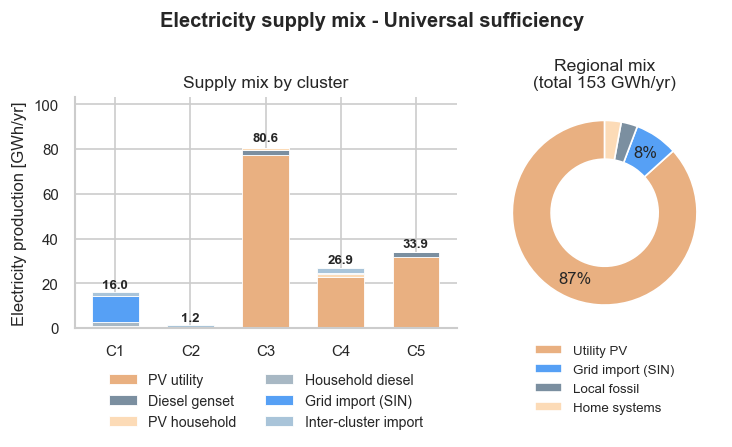

figure\us_supply_mix.png


In [96]:
# -- Figure 1: us_supply_mix.png ---------------------------------------------
order = ['PV_UTILITY', 'GENSET_DIESEL', 'PV_HS', 'HS_DIESEL', 'SIN_IMPORT', 'INTERCLUSTER_IMPORT']
piv = elec_by_region_tech(US['yb'], ['PV_UTILITY', 'GENSET_DIESEL', 'PV_HS', 'HS_DIESEL'])
piv = pd.concat([piv, import_split(US)], axis=1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16 * CM, 9.5 * CM), gridspec_kw={'width_ratios': [1.5, 1]})

x = np.arange(len(REGIONS))
seen = set()
top = stacked_bar(axL, piv, order, x, 0.62, seen=seen)
for xi, t in zip(x, top):
    axL.text(xi, t + t * 0.015 + 0.3, f'{t:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axL.set_xticks(x); axL.set_xticklabels(REGIONS)
axL.set_ylabel('Electricity production [GWh/yr]')
axL.set_title('Supply mix by cluster', fontsize=10.5)
axL.set_ylim(0, top.max() * 1.28)
axL.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)

# Primary supply only (production + true exterior import): inter-cluster
# import is excluded, it is already counted as production at the exporting
# cluster and would otherwise be double-counted here.
cat_vals = {
    'Utility PV':        piv.get('PV_UTILITY', pd.Series(dtype=float)).sum(),
    'Grid import (SIN)': piv.get('SIN_IMPORT', pd.Series(dtype=float)).sum(),
    'Local fossil':      piv.get('GENSET_DIESEL', pd.Series(dtype=float)).sum(),
    'Home systems':      piv.get('PV_HS', pd.Series(dtype=float)).sum() + piv.get('HS_DIESEL', pd.Series(dtype=float)).sum(),
}
cat_colors = {'Utility PV': get_color('PV_UTILITY'), 'Grid import (SIN)': get_color('SIN_IMPORT'),
              'Local fossil': get_color('GENSET_DIESEL'), 'Home systems': get_color('PV_HS')}
cat_vals = {k: v for k, v in cat_vals.items() if v > EPS}
wedges, _, _ = axR.pie(cat_vals.values(), colors=[cat_colors[k] for k in cat_vals],
                        autopct=lambda pct: f'{pct:.0f}%' if pct >= 5 else '',
                        startangle=90, pctdistance=0.78,
                        wedgeprops={'width': 0.42, 'edgecolor': 'white'})
axR.set_title(f'Regional mix\n(total {sum(cat_vals.values()):.0f} GWh/yr)', fontsize=10.5)
axR.legend(wedges, list(cat_vals.keys()), loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=1, frameon=False, fontsize=8)

fig.suptitle('Electricity supply mix - Universal sufficiency', y=1.02, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'us_supply_mix.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()
print(FIG_DIR / 'us_supply_mix.png')


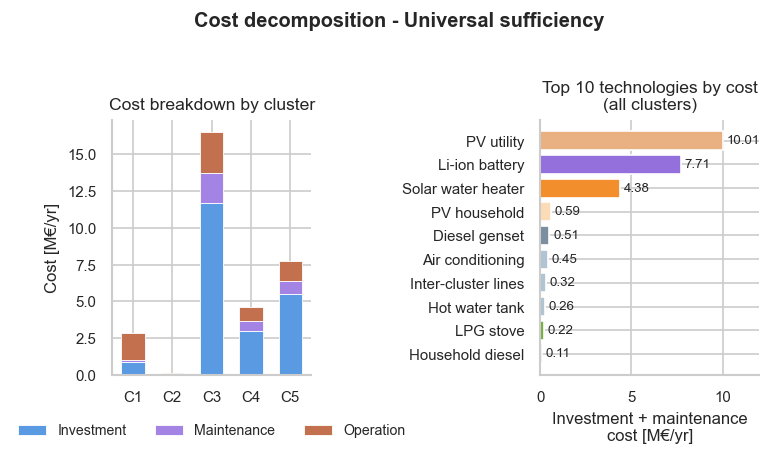

figure\us_cost_decomposition.png


In [97]:
# -- Figure 2: us_cost_decomposition.png -------------------------------------
by_reg = cost_by_region_tbl(US)
by_tech = cost_by_tech_tbl(US).sort_values('total', ascending=False).head(10)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16 * CM, 9.5 * CM), gridspec_kw={'width_ratios': [1, 1.1]})

x = np.arange(len(REGIONS))
bottom = np.zeros(len(REGIONS))
for col in ['C_inv', 'C_maint', 'C_op']:
    axL.bar(x, by_reg[col].values, 0.6, bottom=bottom, color=COST_COLORS[col],
            label=COST_LABELS[col], edgecolor='white', linewidth=0.5)
    bottom += by_reg[col].values
axL.set_xticks(x); axL.set_xticklabels(REGIONS)
axL.set_ylabel('Cost [M€/yr]')
axL.set_title('Cost breakdown by cluster', fontsize=10.5)
axL.set_ylim(0, bottom.max() * 1.05)
axL.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False)

by_tech = by_tech.iloc[::-1]
y = np.arange(len(by_tech))
axR.barh(y, by_tech['total'].values, color=[get_color(t) for t in by_tech.index], edgecolor='white')
axR.set_yticks(y); axR.set_yticklabels([get_label(t) for t in by_tech.index])
axR.set_xlim(0, by_tech['total'].max() * 1.2)
for yi, v in zip(y, by_tech['total'].values):
    axR.text(v + by_tech['total'].max() * 0.02, yi, f'{v:.2f}', va='center', fontsize=8)
axR.set_xlabel('Investment + maintenance\ncost [M€/yr]')
axR.set_title('Top 10 technologies by cost\n(all clusters)', fontsize=10.5)

fig.suptitle('Cost decomposition - Universal sufficiency', y=1.03, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'us_cost_decomposition.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()
print(FIG_DIR / 'us_cost_decomposition.png')


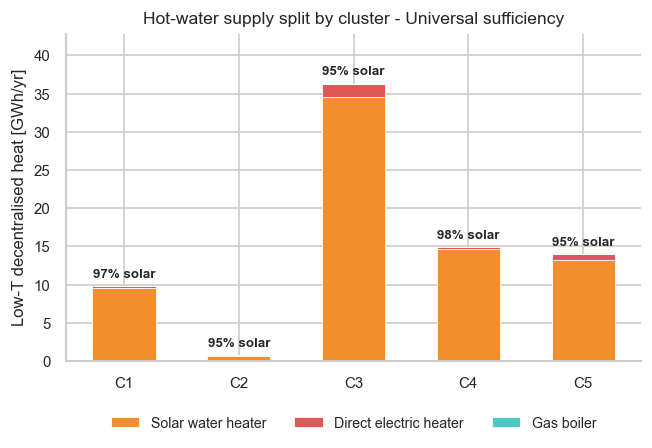

figure\us_hotwater_split.png


In [98]:
# -- Figure 3: us_hotwater_split.png -----------------------------------------
order = ['DEC_SOLAR', 'DEC_DIRECT_ELEC', 'DEC_BOILER_GAS']
d = layer(US['yb'], 'HEAT_LOW_T_DECEN')
d = d[d['Elements'].isin(order) & (d['val'] > EPS) & d['Regions'].isin(REGIONS)]
piv = d.pivot_table(index='Regions', columns='Elements', values='val', aggfunc='sum').reindex(REGIONS).fillna(0)

fig, ax = plt.subplots(figsize=(16 * CM, 9 * CM))
x = np.arange(len(REGIONS))
top = stacked_bar(ax, piv, order, x, 0.55)
tot = piv.sum(axis=1)
share_solar = (piv.get('DEC_SOLAR', pd.Series(0, index=REGIONS)) / tot.replace(0, np.nan) * 100).fillna(0)
for xi, t, s in zip(x, top, share_solar.values):
    ax.text(xi, t + max(top) * 0.02, f'{s:.0f}% solar', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('Low-T decentralised heat [GWh/yr]')
ax.set_title('Hot-water supply split by cluster - Universal sufficiency')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False)
ax.set_ylim(0, max(top) * 1.18 if max(top) > 0 else 1)

fig.subplots_adjust(left=0.14)
fig.savefig(FIG_DIR / 'us_hotwater_split.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()
print(FIG_DIR / 'us_hotwater_split.png')


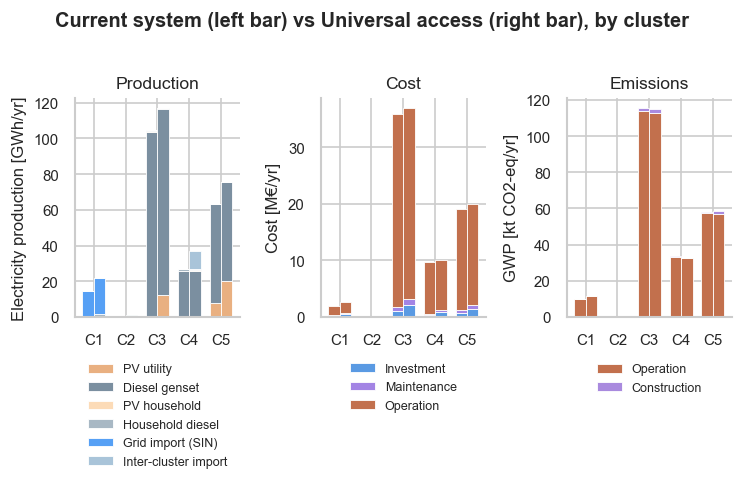

figure\ua_vs_cs_comparison.png


In [99]:
# -- Figure 4: ua_vs_cs_comparison.png ---------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16 * CM, 10.5 * CM))
x = np.arange(len(REGIONS))
w = 0.36
order = ['PV_UTILITY', 'GENSET_DIESEL', 'PV_HS', 'HS_DIESEL', 'SIN_IMPORT', 'INTERCLUSTER_IMPORT']

ax = axes[0]
seen = set()
tops = []
for D, dx in [(CS, -w / 2), (UA, w / 2)]:
    piv = elec_by_region_tech(D['yb'], ['PV_UTILITY', 'GENSET_DIESEL', 'PV_HS', 'HS_DIESEL'])
    piv = pd.concat([piv, import_split(D)], axis=1)
    tops.append(stacked_bar(ax, piv, order, x + dx, w, seen=seen))
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('Electricity production [GWh/yr]')
ax.set_title('Production')
ax.set_ylim(0, max(t.max() for t in tops) * 1.05)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=1, frameon=False, fontsize=7.5)

ax = axes[1]
tops = []
for D, dx in [(CS, -w / 2), (UA, w / 2)]:
    by_reg = cost_by_region_tbl(D)
    bottom = np.zeros(len(REGIONS))
    for col in ['C_inv', 'C_maint', 'C_op']:
        lab = COST_LABELS[col] if D is CS else None
        ax.bar(x + dx, by_reg[col].values, w, bottom=bottom, color=COST_COLORS[col],
               edgecolor='white', linewidth=0.5, label=lab)
        bottom += by_reg[col].values
    tops.append(bottom)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('Cost [M€/yr]')
ax.set_title('Cost')
ax.set_ylim(0, max(t.max() for t in tops) * 1.05)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=1, frameon=False, fontsize=7.5)

ax = axes[2]
gwp_order = ['GWP_op', 'GWP_constr']
tops = []
for D, dx in [(CS, -w / 2), (UA, w / 2)]:
    by_reg = gwp_by_region_tbl(D)
    bottom = np.zeros(len(REGIONS))
    for col in gwp_order:
        lab = GWP_LABELS[col] if D is CS else None
        ax.bar(x + dx, by_reg[col].values, w, bottom=bottom, color=GWP_COLORS[col],
               edgecolor='white', linewidth=0.5, label=lab)
        bottom += by_reg[col].values
    tops.append(bottom)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('GWP [kt CO2-eq/yr]')
ax.set_title('Emissions')
ax.set_ylim(0, max(t.max() for t in tops) * 1.05)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=1, frameon=False, fontsize=7.5)

fig.suptitle('Current system (left bar) vs Universal access (right bar), by cluster', y=1.02, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'ua_vs_cs_comparison.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()
print(FIG_DIR / 'ua_vs_cs_comparison.png')


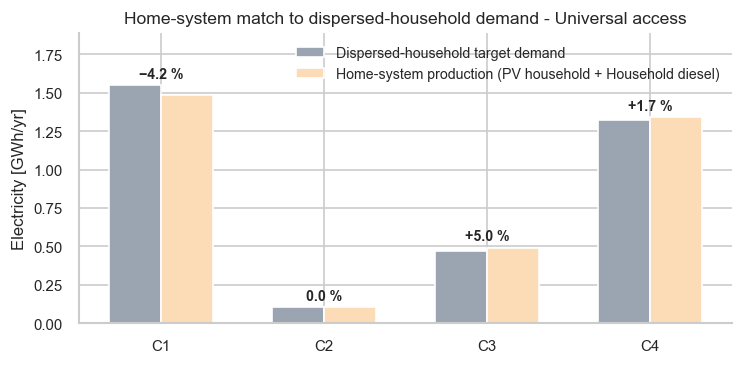

figure\ua_offgrid_match.png


In [100]:
# -- Figure 5: ua_offgrid_match.png ------------------------------------------
target = {'C1': 1.5479, 'C2': 0.1048, 'C3': 0.4681, 'C4': 1.3209}
regs = list(target.keys())
piv = elec_by_region_tech(UA['yb'], ['PV_HS', 'HS_DIESEL'])
actual = (piv.get('PV_HS', pd.Series(0, index=REGIONS)) + piv.get('HS_DIESEL', pd.Series(0, index=REGIONS)))
actual = actual.reindex(regs).fillna(0)

fig, ax = plt.subplots(figsize=(16 * CM, 8 * CM))
x = np.arange(len(regs)); w = 0.32
ax.bar(x - w / 2, [target[r] for r in regs], w, color='#9AA5B1', edgecolor='white', label='Dispersed-household target demand')
ax.bar(x + w / 2, actual.values, w, color=get_color('PV_HS'), edgecolor='white',
       label=f"Home-system production ({get_label('PV_HS')} + {get_label('HS_DIESEL')})")

ymax = max(max(target.values()), actual.max())
for xi, r in zip(x, regs):
    t, a = target[r], actual[r]
    dev = round((a - t) / t * 100, 1) if t > EPS else 0.0
    sign = '' if dev == 0 else ('+' if dev > 0 else '\u2212')  # avoid "-0.0 %" on a rounded-to-zero deviation
    ax.text(xi, max(t, a) + ymax * 0.03, f'{sign}{abs(dev):.1f} %', ha='center', fontsize=8.5, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(regs)
ax.set_ylabel('Electricity [GWh/yr]')
ax.set_title('Home-system match to dispersed-household demand - Universal access')
ax.set_ylim(0, ymax * 1.22)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'ua_offgrid_match.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()
print(FIG_DIR / 'ua_offgrid_match.png')


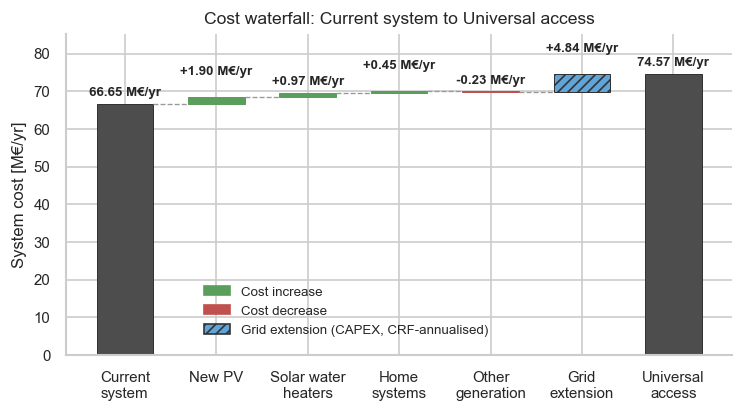

figure\access_cost_waterfall.png


In [101]:
# -- Figure 6: access_cost_waterfall.png -------------------------------------
# Reuses `rows` (Current system / Universal access generation + grid-extension
# cost) already computed in section 10's grid-infrastructure cell.
cs_gen, _, _ = rows['Current system']
ua_gen, ua_ext, ua_total = rows['Universal access']

cs_cost_tech = cost_by_tech_tbl(CS)['total']
ua_cost_tech = cost_by_tech_tbl(UA)['total']

def d(tech):
    return ua_cost_tech.get(tech, 0.0) - cs_cost_tech.get(tech, 0.0)

new_pv = d('PV_UTILITY')
solar_wh = d('DEC_SOLAR') + d('TS_DEC_DIRECT_ELEC') + d('DEC_DIRECT_ELEC') + d('DEC_BOILER_GAS')
home_sys = d('PV_HS') + d('HS_DIESEL') + d('BATT_HS')
other_gen = (ua_gen - cs_gen) - new_pv - solar_wh - home_sys
grid_ext = ua_ext

steps = [
    ('Current\nsystem', cs_gen, 'start'),
    ('New PV', new_pv, 'pos'),
    ('Solar water\nheaters', solar_wh, 'pos'),
    ('Home\nsystems', home_sys, 'pos'),
    ('Other\ngeneration', other_gen, 'neg' if other_gen < 0 else 'pos'),
    ('Grid\nextension', grid_ext, 'ext'),
    ('Universal\naccess', cs_gen + new_pv + solar_wh + home_sys + other_gen + grid_ext, 'end'),
]

ymax = cs_gen + new_pv + solar_wh + home_sys + max(other_gen, 0) + grid_ext + max(cs_gen, ua_total) * 0.14

fig, ax = plt.subplots(figsize=(16 * CM, 9 * CM))
cum = 0.0
colors = {'start': '#4D4D4D', 'end': '#4D4D4D', 'pos': '#5B9E5B', 'neg': '#C0504D', 'ext': '#5DA5DA'}
for i, (label, val, kind) in enumerate(steps):
    if kind in ('start', 'end'):
        bottom, height = 0, val
        cum = val
    else:
        bottom = cum if val >= 0 else cum + val
        height = abs(val)
        cum += val
    hatch = '////' if kind == 'ext' else None
    # pos/neg steps can be a fraction of a M-euro (e.g. -0.23) on an axis
    # spanning tens of M-euro: a 0.6pt dark edge on a ~1px-tall bar swallows
    # the fill colour entirely, so 'Cost decrease' never actually reads red.
    # Match the edge to the fill for those bars instead.
    edge = colors[kind] if kind in ('pos', 'neg') else '#333333'
    ax.bar(i, height, bottom=bottom, width=0.62, color=colors[kind],
           edgecolor=edge, linewidth=0.6, hatch=hatch)
    label_y = bottom + height + ymax * (0.015 + 0.045 * (i % 2))
    txt = f'{val:+.2f}' if kind not in ('start', 'end') else f'{val:.2f}'
    ax.text(i, label_y, f'{txt} M€/yr', ha='center', va='bottom', fontsize=8, fontweight='bold')

cum_track, run = [], 0.0
for label, val, kind in steps:
    if kind == 'start':
        run = val
    elif kind != 'end':
        run += val
    cum_track.append(run)
for i in range(len(steps) - 2):
    ax.plot([i + 0.31, i + 1 - 0.31], [cum_track[i], cum_track[i]], color='#999999', lw=0.8, ls='--')

ax.set_xticks(range(len(steps))); ax.set_xticklabels([s[0] for s in steps])
ax.set_ylabel('System cost [M€/yr]')
ax.set_title('Cost waterfall: Current system to Universal access')
ax.set_ylim(0, ymax)

legend_handles = [
    mpatches.Patch(color=colors['pos'], label='Cost increase'),
    mpatches.Patch(color=colors['neg'], label='Cost decrease'),
    mpatches.Patch(facecolor=colors['ext'], hatch='////', edgecolor='#333333', label='Grid extension (CAPEX, CRF-annualised)'),
]
ax.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.42, 0.02), frameon=False, fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / 'access_cost_waterfall.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()
print(FIG_DIR / 'access_cost_waterfall.png')


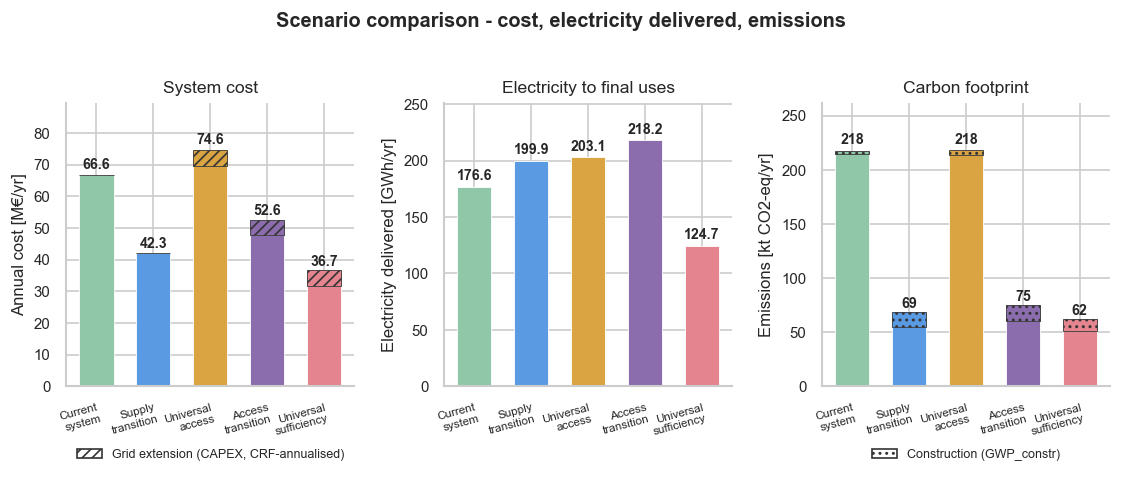

figure\scenario_comparison.png


In [102]:
# -- Figure 7: scenario_comparison.png ---------------------------------------
SCEN_ORDER = ['Current system', 'Supply transition', 'Universal access', 'Access transition', 'Universal sufficiency']
SCEN_XLABELS = {'Current system': 'Current\nsystem', 'Supply transition': 'Supply\ntransition',
                'Universal access': 'Universal\naccess', 'Access transition': 'Access\ntransition',
                'Universal sufficiency': 'Universal\nsufficiency'}
SCEN_DATADIR = {'Current system': DATA / 'reality', 'Supply transition': DATA / 'reality',
                'Universal access': DATA / 'reality_access', 'Access transition': DATA / 'reality_access',
                'Universal sufficiency': DATA / 'sufficiency'}

def elec_tech_consumption(yb, data_dir):
    '''Electricity annually consumed by non-storage end-use technologies, identified
    from their negative ELECTRICITY coefficient in Layers_in_out.csv.'''
    lio = pd.read_csv(Path(data_dir) / '00_INDEP' / 'Layers_in_out.csv', sep=';', index_col=0)
    consumers = lio[lio['ELECTRICITY'] < 0].index
    d = layer(yb, 'ELECTRICITY')
    d = d[d['Regions'].isin(REGIONS) & d['Elements'].isin(consumers) &
          (~d['Elements'].isin(STORAGE_TECHS)) & (d['val'] < -EPS)]
    return -d['val'].sum()

def elec_direct_demand(data_dir):
    '''Direct electricity useful demand: the ELECTRICITY line of Demands.csv
    (all sectors, all clusters) - end-uses met without an explicit conversion tech.'''
    tot = 0.0
    for r in REGIONS:
        dm = pd.read_csv(Path(data_dir) / r / 'Demands.csv', sep=';')
        row = dm[dm['parameter name'] == 'ELECTRICITY']
        cols = [c for c in dm.columns if c not in ('Category', 'Subcategory', 'parameter name', 'Units')]
        tot += row[cols].apply(pd.to_numeric, errors='coerce').sum(axis=1).sum()
    return tot

def elec_delivered(yb, data_dir):
    '''Electricity delivered to final uses = end-use tech consumption + direct demand.'''
    return elec_tech_consumption(yb, data_dir) + elec_direct_demand(data_dir)

gen_cost   = {lab: rows[lab][0] for lab in SCEN_ORDER}
ext_cost   = {lab: rows[lab][1] for lab in SCEN_ORDER}
tot_cost   = {lab: rows[lab][2] for lab in SCEN_ORDER}
elec_deliv = {lab: elec_delivered(DS[lab]['yb'], SCEN_DATADIR[lab]) for lab in SCEN_ORDER}
gwp_tot    = {lab: gwp_by_region_tbl(DS[lab]).sum() for lab in SCEN_ORDER}   # Series: GWP_op, GWP_constr

fig, axes = plt.subplots(1, 3, figsize=(24 * CM, 10 * CM))
x = np.arange(len(SCEN_ORDER))

# -- Panel 1: annual cost, generation (plain) + grid extension (hatched) -----
ax = axes[0]
for xi, lab in zip(x, SCEN_ORDER):
    ax.bar(xi, gen_cost[lab], 0.6, color=SCEN_COLORS[lab], edgecolor='white', linewidth=0.5)
    ax.bar(xi, ext_cost[lab], 0.6, bottom=gen_cost[lab], color=SCEN_COLORS[lab],
           edgecolor='#333333', linewidth=0.5, hatch='////')
    tot = gen_cost[lab] + ext_cost[lab]
    ax.text(xi, tot + tot * 0.015, f'{tot:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([SCEN_XLABELS[l] for l in SCEN_ORDER], fontsize=7,
                                    rotation=15, ha='right', rotation_mode='anchor')
ax.set_ylabel('Annual cost [M€/yr]')
ax.set_title('System cost', fontsize=10.5)
ax.set_ylim(0, max(tot_cost.values()) * 1.2)
ext_patch = mpatches.Patch(facecolor='white', edgecolor='#333333', hatch='////', label='Grid extension (CAPEX, CRF-annualised)')
ax.legend(handles=[ext_patch], loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=False, fontsize=7.5)

# -- Panel 2: electricity delivered to final uses -----------------------------
ax = axes[1]
v = [elec_deliv[l] for l in SCEN_ORDER]
ax.bar(x, v, 0.6, color=[SCEN_COLORS[l] for l in SCEN_ORDER], edgecolor='white', linewidth=0.5)
for xi, val in zip(x, v):
    ax.text(xi, val + max(v) * 0.015, f'{val:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([SCEN_XLABELS[l] for l in SCEN_ORDER], fontsize=7,
                                    rotation=15, ha='right', rotation_mode='anchor')
ax.set_ylabel('Electricity delivered [GWh/yr]')
ax.set_title('Electricity to final uses', fontsize=10.5)
ax.set_ylim(0, max(v) * 1.15)

# -- Panel 3: emissions, operation (plain) + construction (hatched) ----------
ax = axes[2]
for xi, lab in zip(x, SCEN_ORDER):
    op, co = gwp_tot[lab]['GWP_op'], gwp_tot[lab]['GWP_constr']
    ax.bar(xi, op, 0.6, color=SCEN_COLORS[lab], edgecolor='white', linewidth=0.5)
    ax.bar(xi, co, 0.6, bottom=op, color=SCEN_COLORS[lab], edgecolor='#333333', linewidth=0.5, hatch='...')
    ax.text(xi, op + co + (op + co) * 0.015, f'{op + co:.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([SCEN_XLABELS[l] for l in SCEN_ORDER], fontsize=7,
                                    rotation=15, ha='right', rotation_mode='anchor')
ax.set_ylabel('Emissions [kt CO2-eq/yr]')
ax.set_title('Carbon footprint', fontsize=10.5)
ax.set_ylim(0, max(v['GWP_op'] + v['GWP_constr'] for v in gwp_tot.values()) * 1.2)
constr_patch = mpatches.Patch(facecolor='white', edgecolor='#333333', hatch='...', label='Construction (GWP_constr)')
ax.legend(handles=[constr_patch], loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=False, fontsize=7.5)

fig.suptitle('Scenario comparison - cost, electricity delivered, emissions', y=1.03, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'scenario_comparison.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()
print(FIG_DIR / 'scenario_comparison.png')


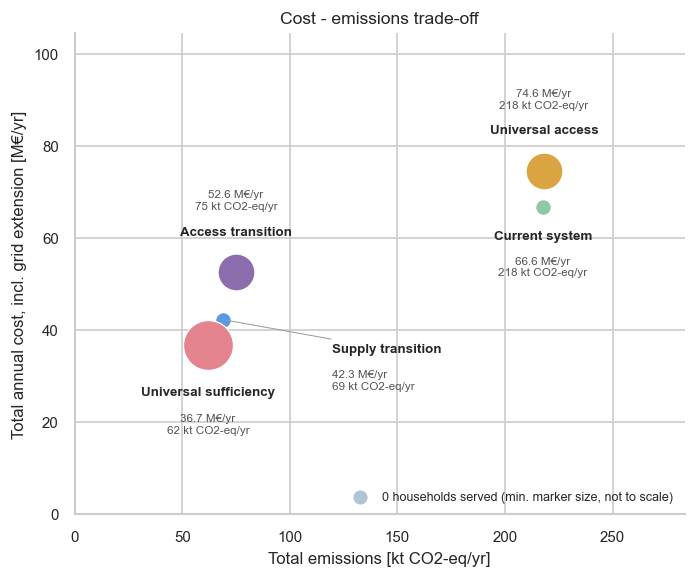

figure\cost_vs_emissions.png


In [103]:
# -- Figure 8: cost_vs_emissions.png ------------------------------------------
# Households connected at a sufficiency consumption level (target demand used to
# size the universal-coverage scenarios, see section 12 / ua_offgrid_match).
HOUSEHOLDS_SUFF = {'Current system': 0, 'Supply transition': 0,
                    'Universal access': 20714, 'Access transition': 20714,
                    'Universal sufficiency': 84209}
MARKER_MIN, MARKER_MAX = 90, 900

def marker_size(n):
    if n <= 0:
        return MARKER_MIN
    return MARKER_MIN + (MARKER_MAX - MARKER_MIN) * (n / max(HOUSEHOLDS_SUFF.values())) ** 0.5

emissions = {lab: gwp_tot[lab]['GWP_op'] + gwp_tot[lab]['GWP_constr'] for lab in SCEN_ORDER}

fig, ax = plt.subplots(figsize=(15 * CM, 12.5 * CM))

# Current system sits almost directly below Universal access (same emissions,
# lower cost), and Supply transition almost directly above Universal
# sufficiency: push each point's labels to the opposite side of its neighbour
# (above/below) so the two never collide, then push the value line further out
# still, past the scenario-name line, on that same side.
# Access transition sits close to Supply transition (emissions 75 vs 69, cost
# 52.6 vs 42.3): nothing else sits directly above Access transition, so it
# uses the plain above/below mechanism like every other point.
# Supply transition itself is boxed in: Universal sufficiency's marker sits
# almost touching it below-left, and Access transition's marker sits close
# above-right, so there is no free spot next to its own marker. Its label is
# placed further out (down-right) with a thin leader line back to the point.
label_above = {'Current system': False, 'Universal access': True,
                'Universal sufficiency': False, 'Access transition': True}

for lab in SCEN_ORDER:
    s = marker_size(HOUSEHOLDS_SUFF[lab])
    r = (s / np.pi) ** 0.5  # marker radius in points, to clear it with the labels
    ax.scatter(emissions[lab], tot_cost[lab], s=s, color=SCEN_COLORS[lab],
               edgecolor='white', linewidth=0.8, zorder=3)
    if lab == 'Supply transition':
        ax.annotate(lab, (emissions[lab], tot_cost[lab]), xytext=(r + 60, -14),
                    textcoords='offset points', ha='left', va='top', fontsize=8, fontweight='bold',
                    arrowprops=dict(arrowstyle='-', color='#999999', lw=0.6, shrinkA=0, shrinkB=2))
        ax.annotate(f'{tot_cost[lab]:.1f} M€/yr\n{emissions[lab]:.0f} kt CO2-eq/yr',
                    (emissions[lab], tot_cost[lab]), xytext=(r + 60, -30),
                    textcoords='offset points', ha='left', va='top', fontsize=7, color='#555555')
        continue
    sign = 1 if label_above[lab] else -1
    va = 'bottom' if label_above[lab] else 'top'
    ax.annotate(lab, (emissions[lab], tot_cost[lab]), xytext=(0, sign * (r + 8)),
                textcoords='offset points', ha='center', va=va, fontsize=8, fontweight='bold')
    ax.annotate(f'{tot_cost[lab]:.1f} M€/yr\n{emissions[lab]:.0f} kt CO2-eq/yr',
                (emissions[lab], tot_cost[lab]), xytext=(0, sign * (r + 24)),
                textcoords='offset points', ha='center', va=va, fontsize=7, color='#555555')

ax.set_xlabel('Total emissions [kt CO2-eq/yr]')
ax.set_ylabel('Total annual cost, incl. grid extension [M€/yr]')
ax.set_title('Cost - emissions trade-off', fontsize=10.5)
ax.set_xlim(0, max(emissions.values()) * 1.3)
ax.set_ylim(0, max(tot_cost.values()) * 1.4)

size_note = ax.scatter([], [], s=MARKER_MIN, color='#B0C4D4', edgecolor='white',
                        label='0 households served (min. marker size, not to scale)')
ax.legend(handles=[size_note], loc='lower right', frameon=False, fontsize=7.5)

plt.tight_layout()
fig.savefig(FIG_DIR / 'cost_vs_emissions.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()
print(FIG_DIR / 'cost_vs_emissions.png')


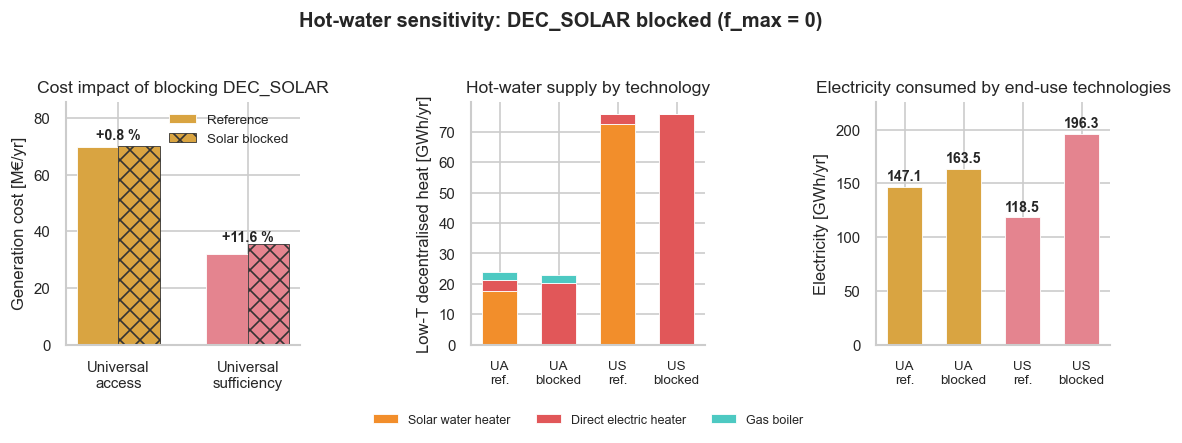

figure\hotwater_sensitivity.png


In [104]:
# -- Figure 9: hotwater_sensitivity.png ----------------------------------------
# DEC_SOLAR (solar water heater) forced to f_max = 0, Universal access & Universal
# sufficiency only - isolates how much of the hot-water / cost outcome relies on it.
SENS_ROOT = ROOT / '_sensitivity_DEC_SOLAR_fmax0'
SENS_CASES = ['UA ref', 'UA blocked', 'US ref', 'US blocked']
SENS_XLABELS = {'UA ref': 'UA\nref.', 'UA blocked': 'UA\nblocked',
                'US ref': 'US\nref.', 'US blocked': 'US\nblocked'}
SENS_BASE = {
    'UA ref':     ROOT / 'norte_amazonia_reality_access_2025' / 'outputs',
    'UA blocked': SENS_ROOT / 'reality_access' / 'outputs',
    'US ref':     ROOT / 'norte_amazonia_sufficiency_2025' / 'outputs',
    'US blocked': SENS_ROOT / 'sufficiency' / 'outputs',
}
SENS_DATADIR = {'UA ref': DATA / 'reality_access', 'UA blocked': DATA / 'reality_access',
                 'US ref': DATA / 'sufficiency', 'US blocked': DATA / 'sufficiency'}
SENS_COLORS = {'UA ref': SCEN_COLORS['Universal access'], 'UA blocked': SCEN_COLORS['Universal access'],
               'US ref': SCEN_COLORS['Universal sufficiency'], 'US blocked': SCEN_COLORS['Universal sufficiency']}

SENS = {lab: load_scenario(base) for lab, base in SENS_BASE.items()}
for lab, D in SENS.items():
    si = D['solve']
    status = float(si[si.iloc[:, 0].astype(str).str.contains('solve_result_num', na=False)].iloc[0, 1])
    assert status == 0, f'{lab}: solve_result_num = {status} (not optimal) - do not trust this run'

sens_cost = {lab: D['total_cost'][D['total_cost']['Regions'].isin(REGIONS)]['TotalCost'].sum()
             for lab, D in SENS.items()}
sens_elec = {lab: elec_tech_consumption(D['yb'], SENS_DATADIR[lab]) for lab, D in SENS.items()}

hw_order = ['DEC_SOLAR', 'DEC_DIRECT_ELEC', 'DEC_BOILER_GAS']
hw = {}
for lab, D in SENS.items():
    d = layer(D['yb'], 'HEAT_LOW_T_DECEN')
    d = d[d['Elements'].isin(hw_order) & (d['val'] > EPS) & d['Regions'].isin(REGIONS)]
    hw[lab] = d.groupby('Elements')['val'].sum().reindex(hw_order).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(24 * CM, 9.5 * CM))

# -- Panel 1: generation cost, reference vs solar-blocked, per scenario ------
ax = axes[0]
groups = ['UA', 'US']
xg = np.arange(len(groups)); w = 0.32
for i, grp in enumerate(groups):
    ref_v, blk_v = sens_cost[f'{grp} ref'], sens_cost[f'{grp} blocked']
    ax.bar(xg[i] - w / 2, ref_v, w, color=SENS_COLORS[f'{grp} ref'], edgecolor='white',
           linewidth=0.5, label='Reference' if i == 0 else None)
    ax.bar(xg[i] + w / 2, blk_v, w, color=SENS_COLORS[f'{grp} blocked'], edgecolor='#333333',
           linewidth=0.5, hatch='xx', label='Solar blocked' if i == 0 else None)
    gap = (blk_v - ref_v) / ref_v * 100
    ax.text(xg[i], max(ref_v, blk_v) * 1.03, f'{gap:+.1f} %', ha='center', fontsize=8.5, fontweight='bold')
ax.set_xticks(xg); ax.set_xticklabels(['Universal\naccess', 'Universal\nsufficiency'])
ax.set_ylabel('Generation cost [M€/yr]')
ax.set_title('Cost impact of blocking DEC_SOLAR', fontsize=10.5)
ax.set_ylim(0, max(sens_cost.values()) * 1.22)
ax.legend(loc='upper right', frameon=False, fontsize=8)

# -- Panel 2: hot-water supply by technology, all four cases -----------------
ax = axes[1]
x2 = np.arange(len(SENS_CASES))
bottom = np.zeros(len(SENS_CASES))
for tech in hw_order:
    vals = np.array([hw[lab][tech] for lab in SENS_CASES])
    ax.bar(x2, vals, 0.6, bottom=bottom, color=get_color(tech), edgecolor='white',
           linewidth=0.5, label=get_label(tech))
    bottom += vals
ax.set_xticks(x2); ax.set_xticklabels([SENS_XLABELS[l] for l in SENS_CASES], fontsize=8)
ax.set_ylabel('Low-T decentralised heat [GWh/yr]')
ax.set_title('Hot-water supply by technology', fontsize=10.5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=3, frameon=False, fontsize=7.5)

# -- Panel 3: electricity delivered to final uses, all four cases ------------
ax = axes[2]
v3 = [sens_elec[lab] for lab in SENS_CASES]
ax.bar(x2, v3, 0.6, color=[SENS_COLORS[l] for l in SENS_CASES], edgecolor='white', linewidth=0.5)
for xi, val in zip(x2, v3):
    ax.text(xi, val + max(v3) * 0.015, f'{val:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(x2); ax.set_xticklabels([SENS_XLABELS[l] for l in SENS_CASES], fontsize=8)
ax.set_ylabel('Electricity [GWh/yr]')
ax.set_title('Electricity consumed by end-use technologies', fontsize=10.5)
ax.set_ylim(0, max(v3) * 1.15)

fig.suptitle('Hot-water sensitivity: DEC_SOLAR blocked (f_max = 0)', y=1.03, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'hotwater_sensitivity.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()
print(FIG_DIR / 'hotwater_sensitivity.png')
